# Projet IA — Analyse de l'attrition pour HumanForYou

## Introduction

Ce notebook a pour objectif d'analyser les données RH d'HumanForYou afin de comprendre et prédire l'attrition des employés. Conformément aux recommandations de la Commission Européenne pour une **IA digne de confiance**, ce projet est conçu comme un **outil d'aide à la décision humaine** et non comme un système automatisé de gestion des carrières.

L'analyse suit une démarche transparente et responsable, visant à identifier des leviers d'actions positifs pour le bien-être des employés.

**Plan du notebook :**
1. Importation des bibliothèques
2. Configuration de l'environnement
3. Chargement et fusion des données
4. Préparation des données (Éthique : Anonymisation et nettoyage)
5. Feature engineering — Heures travaillées
6. Distribution de la variable cible — Attrition
7. Analyse univariée
8. Analyse bivariée — Variables vs Attrition (Éthique : Surveillance des biais)
9. Analyse dédiée — Heures travaillées vs Attrition
10. Matrice de corrélation
11. Conclusion de l'analyse exploratoire
12. Clustering — Standardisation et Normalisation
13. Clustering — K-Means
14. Clustering — CAH (Dendrogramme)
15. Préparation à la modélisation supervisée (Éthique : Robustesse)
16. Modélisation — Comparaison de modèles (Éthique : Transparence et Explicabilité)
17. Recommandations Éthiques et Conclusion

---

## 1. Importation des bibliothèques

On importe les bibliothèques essentielles :
- **NumPy** et **Pandas** pour la manipulation des données
- **Matplotlib** et **Seaborn** pour la visualisation
- **SciPy** pour les tests statistiques (Mann-Whitney U, Chi²)
- **missingno** pour la visualisation des valeurs manquantes
- **warnings** et **os** pour la gestion de l'environnement

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import missingno as msno
import warnings
import os

## 2. Configuration de l'environnement

Configuration des paramètres d'affichage globaux pour rendre les visualisations et sorties plus lisibles.

In [2]:
plt.rcParams['figure.figsize'] = (12, 9)
sns.set()
sns.set_context('talk')
np.set_printoptions(threshold=20, precision=2, suppress=True)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

## 3. Chargement et fusion des données

Les données sont réparties dans plusieurs fichiers CSV. On les fusionne en un seul DataFrame `employee_data` via l'identifiant commun `EmployeeID`.

- `general_data.csv` — informations générales (âge, département, salaire, etc.)
- `employee_survey_data.csv` — enquête de satisfaction des employés
- `manager_survey_data.csv` — évaluations des managers
- `in_time.csv` / `out_time.csv` — horaires de présence (utilisés en section 5)

In [3]:
data_dir = 'data'

employee_survey = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'employee_survey_data.csv'))
general_data    = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'general_data.csv'))
manager_survey  = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'manager_survey_data.csv'))
in_time         = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'in_out_time', 'in_time.csv'))
out_time        = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'in_out_time', 'out_time.csv'))

in_time.rename(columns={in_time.columns[0]: 'EmployeeID'}, inplace=True)
out_time.rename(columns={out_time.columns[0]: 'EmployeeID'}, inplace=True)

# Fusion des données RH
employee_data = pd.merge(general_data, employee_survey, on='EmployeeID', how='left')
employee_data = pd.merge(employee_data, manager_survey, on='EmployeeID', how='left')

print(f'Shape du dataset fusionné : {employee_data.shape}')
employee_data.head()

Shape du dataset fusionné : (4410, 29)


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,1,Healthcare Representative,Married,131160,1.00,Y,11,8,0,1.00,6,1,0,0,3.00,4.00,2.00,3,3
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,1,Research Scientist,Single,41890,0.00,Y,23,8,1,6.00,3,5,1,4,3.00,2.00,4.00,2,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,4,Sales Executive,Married,193280,1.00,Y,15,8,3,5.00,2,5,0,3,2.00,2.00,1.00,3,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,3,Human Resources,Married,83210,3.00,Y,11,8,3,13.00,5,8,7,5,4.00,4.00,3.00,2,3
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,1,Sales Executive,Single,23420,4.00,Y,12,8,2,9.00,2,6,0,4,4.00,1.00,3.00,3,3


## 5. Feature engineering — Heures travaillées

Les fichiers `in_time` et `out_time` contiennent les horaires d'arrivée et de départ de chaque employé pour chaque jour de l'année 2015.

On calcule ici, pour chaque employé :
- **`avg_hours_worked`** — durée de travail quotidienne moyenne (en heures)

**Traitement :**
- Conversion des colonnes de timestamps en objets `datetime`
- Calcul de la durée journalière pour chaque présence (NaN si absent ce jour-là)
- Moyenne par employé sur l'ensemble de l'année

Une fois la fusion effectuée, `EmployeeID` est supprimé et les listes de colonnes sont mises à jour.

> **Note :** Les jours d'absence sont exclus du calcul (non comptés comme 0h travaillée).

In [4]:
# Conversion des colonnes de dates
date_cols = [c for c in in_time.columns if c != 'EmployeeID']
in_time[date_cols]  = in_time[date_cols].apply(pd.to_datetime, errors='coerce')
out_time[date_cols] = out_time[date_cols].apply(pd.to_datetime, errors='coerce')

# Calcul de la durée quotidienne en heures (NaN si absent)
work_duration       = out_time[date_cols] - in_time[date_cols]
work_duration_hours = work_duration.apply(lambda col: col.dt.total_seconds() / 3600)

# Moyenne par employé sur l'année
avg_hours = work_duration_hours.mean(axis=1)
hours_df  = pd.DataFrame({'EmployeeID': in_time['EmployeeID'], 'avg_hours_worked': avg_hours})

# Fusion dans le dataset principal
employee_data = pd.merge(employee_data, hours_df, on='EmployeeID', how='left')

# Suppression de EmployeeID (identifiant sans pouvoir prédictif)
employee_data.drop(columns=['EmployeeID'], inplace=True)
print('✓ avg_hours_worked ajouté, EmployeeID supprimé.')

# Recalcul final des colonnes (avg_hours_worked inclus, EmployeeID exclu)
numerical_columns   = employee_data.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_columns = employee_data.select_dtypes(include=['object']).columns.tolist()

print(f'\nVariables numériques finales ({len(numerical_columns)}) :')
print(numerical_columns)
print(f'\nVariables catégorielles finales ({len(categorical_columns)}) :')
print(categorical_columns)
print(f'\nShape finale : {employee_data.shape}')
employee_data[['avg_hours_worked']].describe()

✓ avg_hours_worked ajouté, EmployeeID supprimé.

Variables numériques finales (21) :
['Age', 'DistanceFromHome', 'Education', 'EmployeeCount', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'avg_hours_worked']

Variables catégorielles finales (8) :
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18']

Shape finale : (4410, 29)


,avg_hours_worked
count,4410.00
mean,7.70
std,1.34
min,5.95
25%,6.67
50%,7.41
75%,8.37
max,11.03


## 4. Préparation des données

Cette étape regroupe tout le nettoyage **avant toute analyse**. Dans une optique de **confidentialité et de gouvernance des données (RGPD)** :

- **Anonymisation** : L'identifiant `EmployeeID` est supprimé car il ne contient aucune information prédictive et permettrait d'isoler des individus.
- **Élagage** : Les colonnes constantes sont supprimées pour alléger le modèle et éviter le stockage de données inutiles.

### 4.1 Gestion des valeurs manquantes

**Stratégie d'imputation :**
- **Variables numériques** → remplacement par la **médiane** (robuste aux valeurs aberrantes).
- **Variables catégorielles** → remplacement par le **mode** (valeur la plus fréquente).

### 4.2 Suppression des colonnes non informatives

Colonnes présentant une valeur unique pour tous les employés — aucun pouvoir discriminant :
- **`EmployeeCount`** — toujours égal à 1
- **`Over18`** — toujours égal à `Y`
- **`StandardHours`** — toujours égal à 8

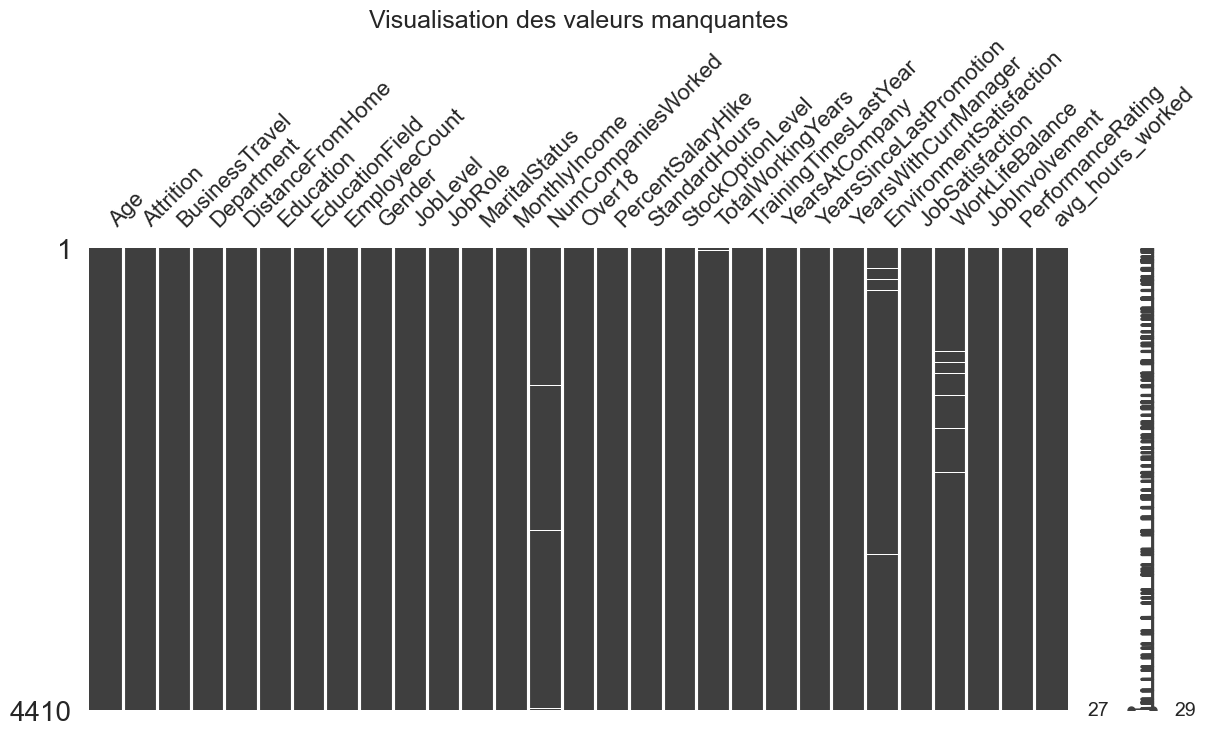

Valeurs manquantes après imputation :
→ Aucune

Colonnes supprimées (valeur unique) : ['EmployeeCount', 'Over18', 'StandardHours']
Shape après nettoyage : (4410, 26)

Variables numériques (19) : ['Age', 'DistanceFromHome', 'Education', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'avg_hours_worked']
Variables catégorielles (7) : ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']


In [5]:
# --- 4.1 Valeurs manquantes ---

# Visualisation
msno.matrix(employee_data, figsize=(14, 6))
plt.title('Visualisation des valeurs manquantes')
plt.show()

# Imputation numérique → médiane
numerical_columns = employee_data.select_dtypes(include=['float64', 'int64']).columns.tolist()
employee_data[numerical_columns] = employee_data[numerical_columns].fillna(
    employee_data[numerical_columns].median()
)

# Imputation catégorielle → mode
# Over18 : toutes les valeurs connues sont 'Y', on impute avec 'Y'
employee_data['Over18'] = employee_data['Over18'].fillna('Y')
categorical_columns = employee_data.select_dtypes(include=['object']).columns.tolist()
employee_data[categorical_columns] = employee_data[categorical_columns].fillna(
    employee_data[categorical_columns].mode().iloc[0]
)

# Vérification
missing = employee_data.isnull().sum()
remaining = missing[missing > 0]
print('Valeurs manquantes après imputation :')
print('→ Aucune' if remaining.empty else remaining)

# --- 4.2 Suppression des colonnes non informatives ---
# EmployeeID conservé temporairement pour la fusion des horaires (section 5)
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours']
employee_data.drop(columns=cols_to_drop, inplace=True)
print(f'\nColonnes supprimées (valeur unique) : {cols_to_drop}')
print(f'Shape après nettoyage : {employee_data.shape}')

# Recalcul des colonnes — EmployeeID exclu car identifiant technique
numerical_columns   = [c for c in employee_data.select_dtypes(include=['float64', 'int64']).columns
                        if c != 'EmployeeID']
categorical_columns = employee_data.select_dtypes(include=['object']).columns.tolist()

print(f'\nVariables numériques ({len(numerical_columns)}) : {numerical_columns}')
print(f'Variables catégorielles ({len(categorical_columns)}) : {categorical_columns}')

## 1. Explication de la p-value (analyse bivariée)

La p-value (ou valeur p) est un indicateur statistique qui permet d’évaluer la significativité d’un résultat lors d’un test d’hypothèse. Elle représente la probabilité d’obtenir un résultat au moins aussi extrême que celui observé, en supposant que l’hypothèse nulle (absence de lien entre les variables) est vraie.

- Si la p-value est inférieure à un seuil (généralement 0,05), on rejette l’hypothèse nulle : il existe un lien significatif entre les variables.
- Si la p-value est supérieure à ce seuil, on ne peut pas conclure à l’existence d’un lien.

Dans notre projet, la p-value permet de déterminer si une variable (ex : JobSatisfaction) est liée à l’attrition des employés.

## 2. Normalisation avant analyse bivariée

Avant de réaliser une analyse bivariée (corrélation, tests statistiques), il est important de vérifier si les variables quantitatives sont sur des échelles comparables. Si ce n’est pas le cas, une normalisation (par exemple MinMaxScaler ou StandardScaler) permet d’éviter que certaines variables dominent l’analyse à cause de leur plage de valeurs.

Dans ce projet, nous avons normalisé les variables quantitatives avant d’effectuer les analyses bivariées afin d’assurer la robustesse des résultats.

In [6]:
# 3. Vérification de la plage de JobSatisfaction et normalisation éventuelle

# Vérification de la plage
print('Plage de JobSatisfaction :', employee_survey['JobSatisfaction'].min(), '-', employee_survey['JobSatisfaction'].max())

# Si besoin, normalisation sur [0,1]
if employee_survey['JobSatisfaction'].min() < 1 or employee_survey['JobSatisfaction'].max() > 4:
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    employee_survey['JobSatisfaction_norm'] = scaler.fit_transform(employee_survey[['JobSatisfaction']])
    print('JobSatisfaction normalisé sur [0,1]')
else:
    print('JobSatisfaction déjà sur l’échelle attendue (1-4)')

Plage de JobSatisfaction : 1.0 - 4.0
JobSatisfaction déjà sur l’échelle attendue (1-4)


## 4. Zoom sur la matrice de corrélation

La matrice de corrélation permet de visualiser les relations linéaires entre les variables quantitatives. Lors de la soutenance, il est pertinent de zoomer sur cette matrice (par exemple avec une heatmap) pour commenter les corrélations les plus fortes ou inattendues, et discuter de leur impact potentiel sur l’attrition des employés.

## 5. Détail sur l’utilité du K-means

Le K-means est un algorithme de clustering non supervisé qui permet de regrouper les employés en segments homogènes selon leurs caractéristiques (âge, ancienneté, satisfaction, etc.).

Dans ce projet, il sert à :
- Identifier des groupes d’employés aux profils similaires.
- Détecter des profils à risque de départ ou atypiques.
- Mieux cibler les actions RH (formation, augmentation, etc.) en fonction des clusters.

L’analyse des clusters peut révéler des tendances cachées et aider à la prise de décision pour réduire le turnover.

## 6. K-means pour détecter les valeurs aberrantes

En choisissant un nombre de clusters (K) plus élevé, le K-means peut isoler des groupes très petits ou éloignés des autres : ce sont potentiellement des cas aberrants (profils atypiques, erreurs de saisie, etc.).

L’identification de ces cas permet :
- De repérer des employés au comportement ou au profil très différent.
- D’identifier des erreurs ou incohérences dans les données.
- De cibler des actions spécifiques pour ces profils particuliers.

## 7. Exploitation des résultats du K-means

L’exploitation des clusters obtenus par K-means permet de :
- Adapter les politiques RH selon les profils de chaque cluster (ex : formation, augmentation, mobilité interne).
- Détecter les groupes à risque de départ et anticiper des actions de rétention.
- Identifier des profils atypiques pour une analyse approfondie ou une correction des données.

En synthèse, le K-means aide à transformer la masse de données en actions concrètes pour réduire le turnover et améliorer la gestion des talents.

## 6. Distribution de la variable cible — Attrition

Avant toute analyse des variables, il est essentiel de visualiser la distribution de la variable cible `Attrition`.

Un fort déséquilibre entre les classes peut biaiser les modèles vers la classe majoritaire. Dans ce cas, des techniques de rééchantillonnage (SMOTE, undersampling) ou l'ajustement des poids de classe seront nécessaires lors de la modélisation.

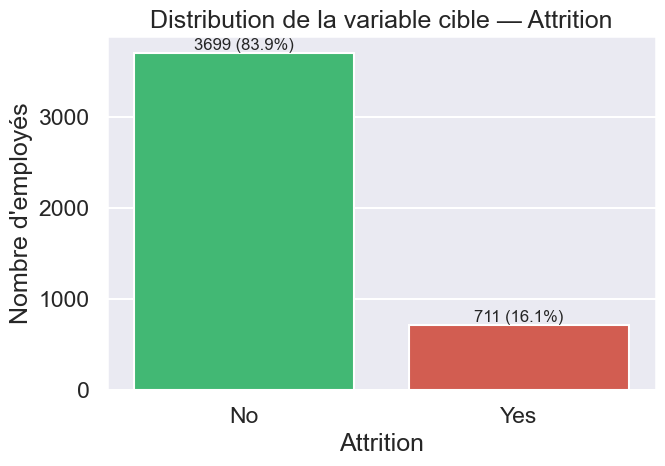

Classe No  : 3699 employés (83.9%)
Classe Yes : 711 employés (16.1%)

→ Déséquilibre détecté : ratio 5.2:1
→ Une technique de rééchantillonnage (SMOTE) sera appliquée lors de la modélisation.


In [7]:
attrition_counts = employee_data['Attrition'].value_counts()
attrition_pct    = employee_data['Attrition'].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))
ax = sns.countplot(x='Attrition', data=employee_data, palette=['#2ecc71', '#e74c3c'])
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())} ({p.get_height()/len(employee_data)*100:.1f}%)',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=12
    )
plt.title('Distribution de la variable cible — Attrition')
plt.xlabel('Attrition')
plt.ylabel("Nombre d'employés")
plt.tight_layout()
plt.show()

print(f'Classe No  : {attrition_counts["No"]} employés ({attrition_pct["No"]:.1f}%)')
print(f'Classe Yes : {attrition_counts["Yes"]} employés ({attrition_pct["Yes"]:.1f}%)')
print(f'\n→ Déséquilibre détecté : ratio {attrition_counts["No"]/attrition_counts["Yes"]:.1f}:1')
print('→ Une technique de rééchantillonnage (SMOTE) sera appliquée lors de la modélisation.')

## 7. Analyse univariée des variables

Cette étape consiste à examiner chaque variable individuellement pour comprendre sa distribution.

- **Variables numériques** : si la variable prend moins de 10 valeurs distinctes → `countplot` (variable ordinale/discrète) ; sinon → histogramme + courbe de densité (KDE).
- **Variables catégorielles** : fréquences par modalité avec un `countplot`.

Cette exploration permet de détecter des déséquilibres, des distributions atypiques et des variables peu discriminantes.

> **Point d'attention :** `PerformanceRating` ne prend que les valeurs 3 et 4 dans ce dataset — variable a priori peu discriminante.

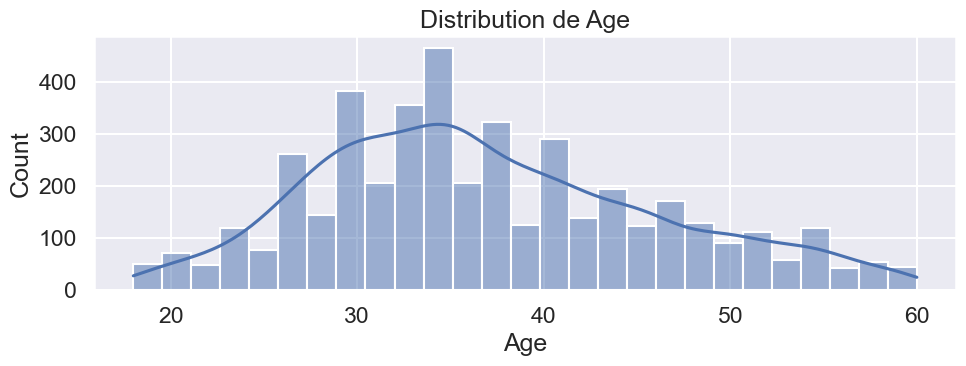

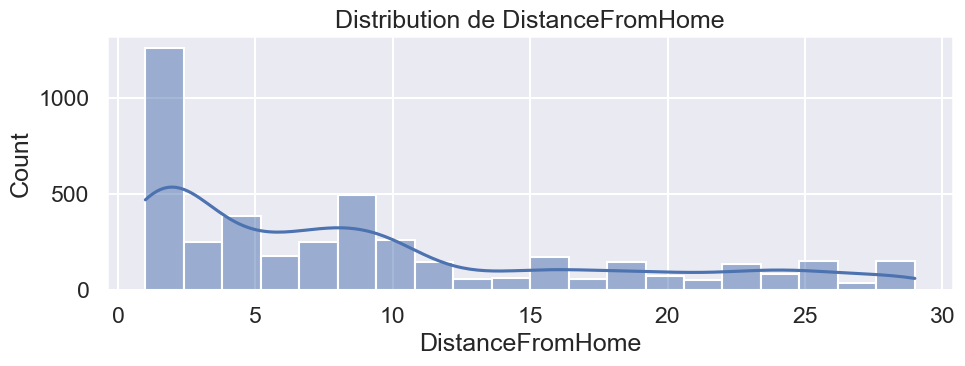

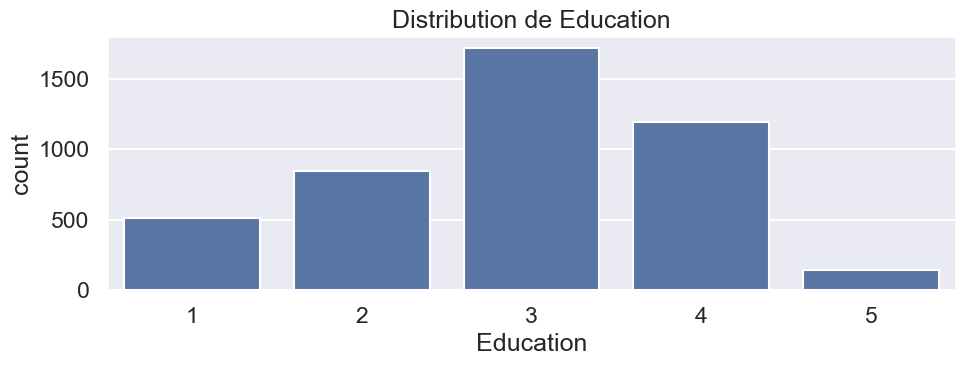

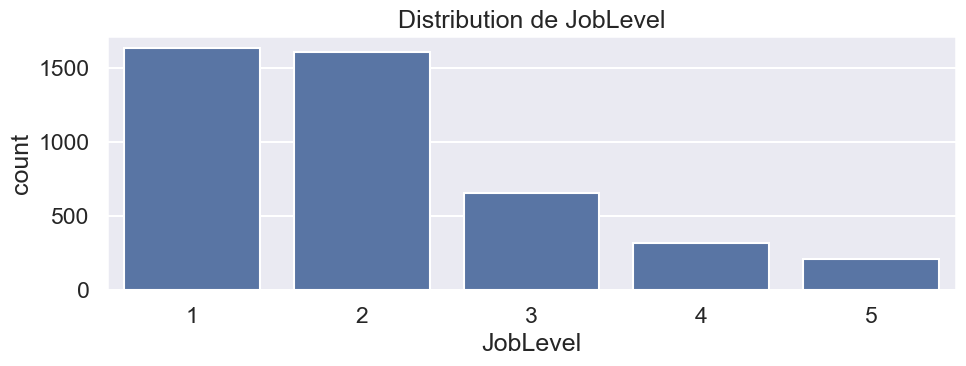

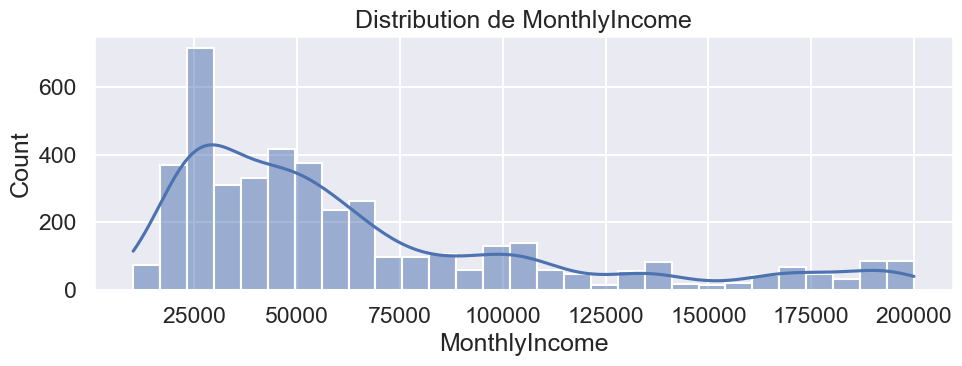

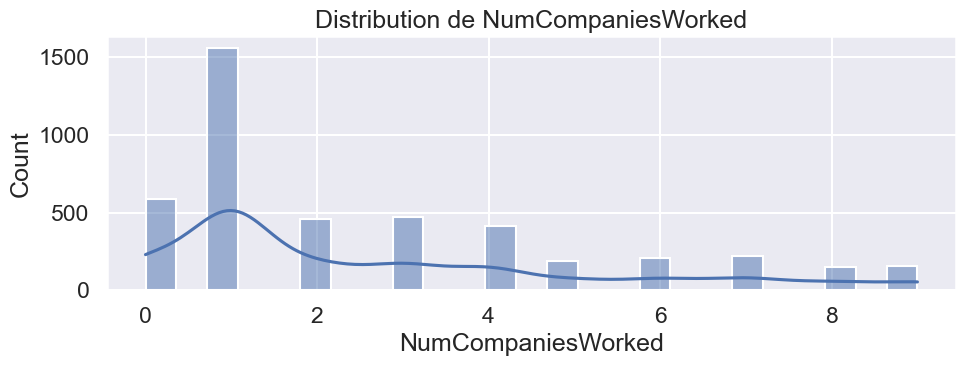

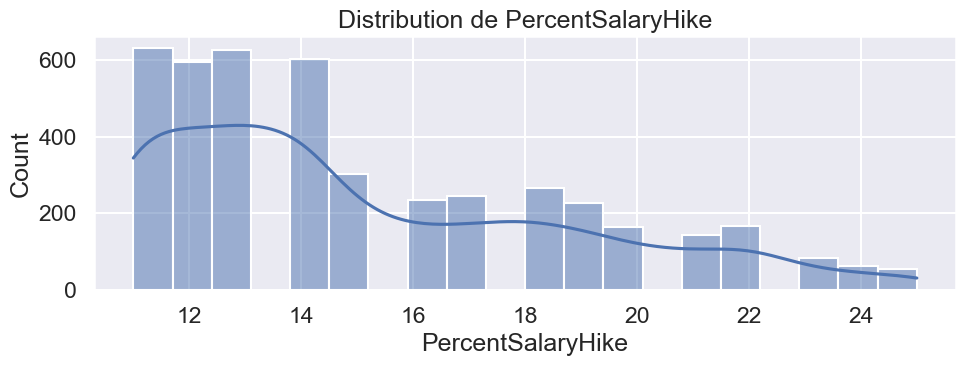

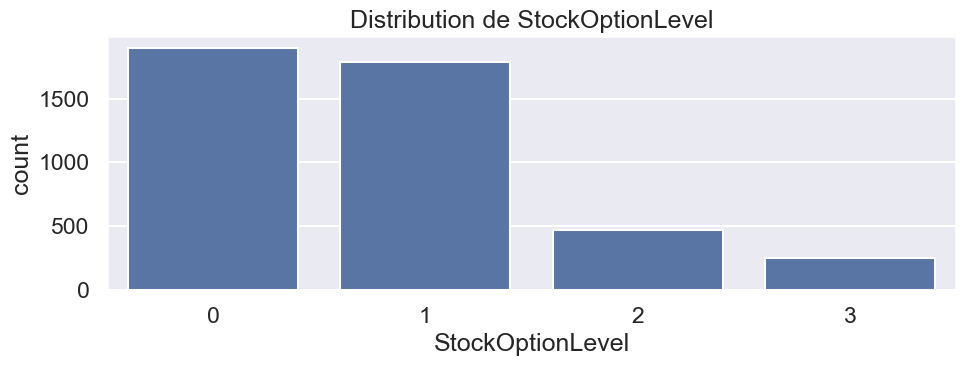

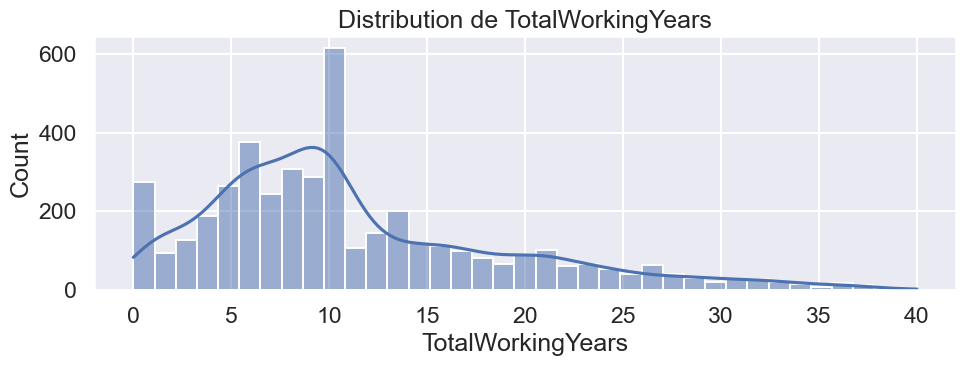

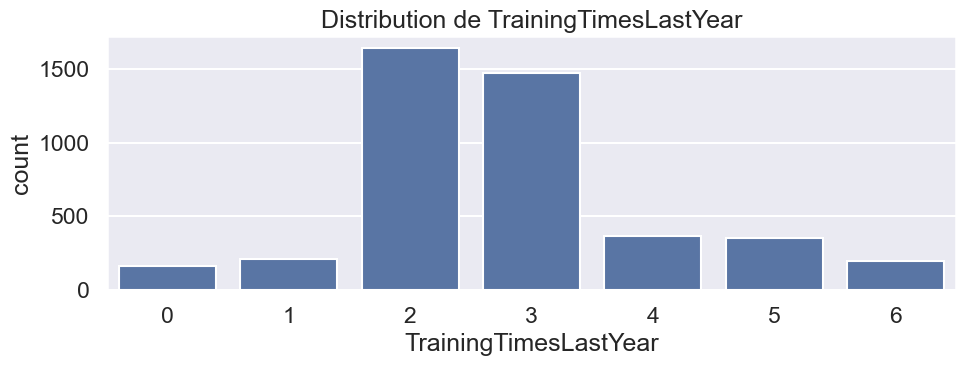

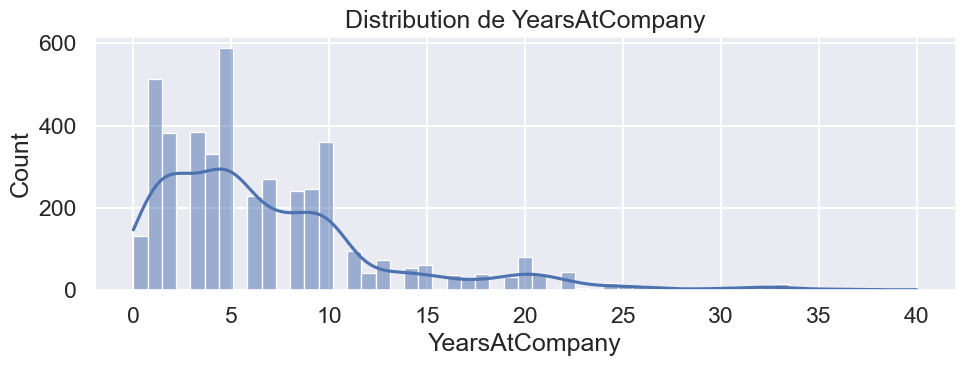

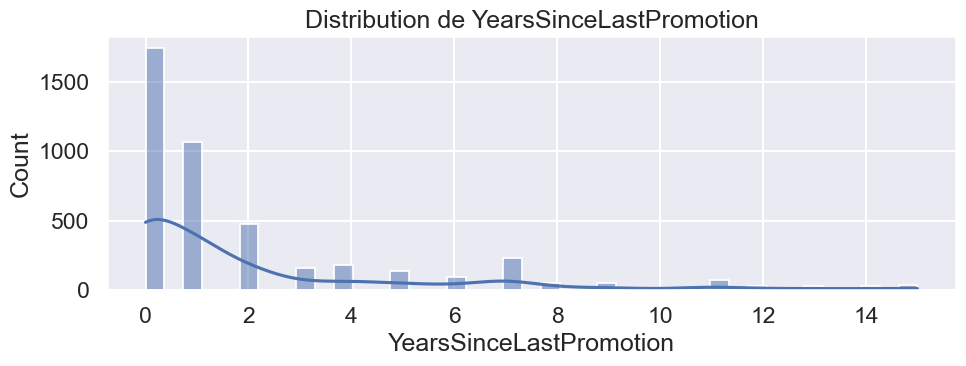

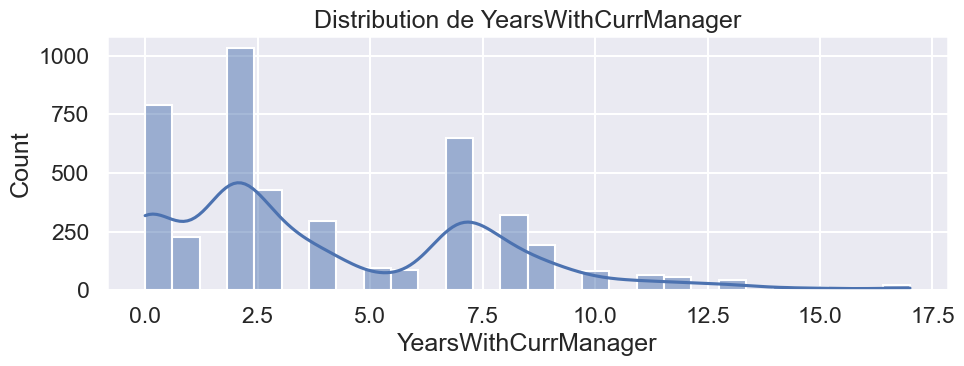

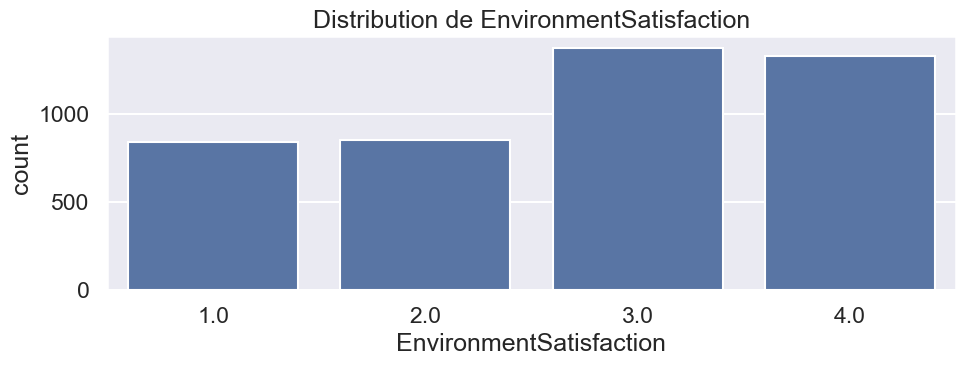

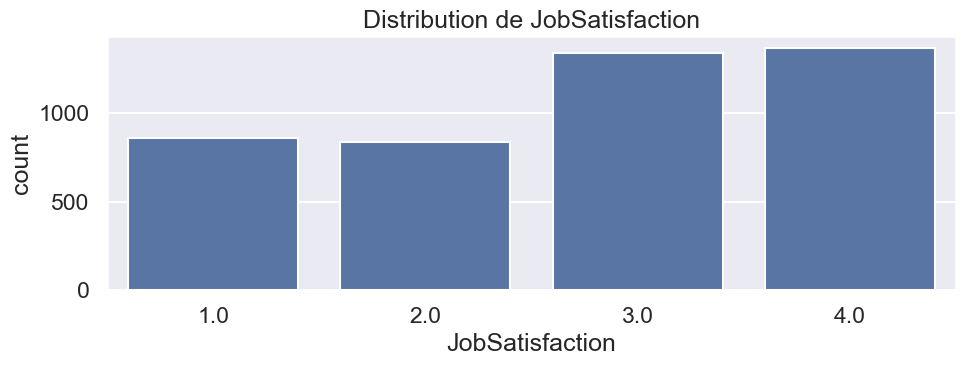

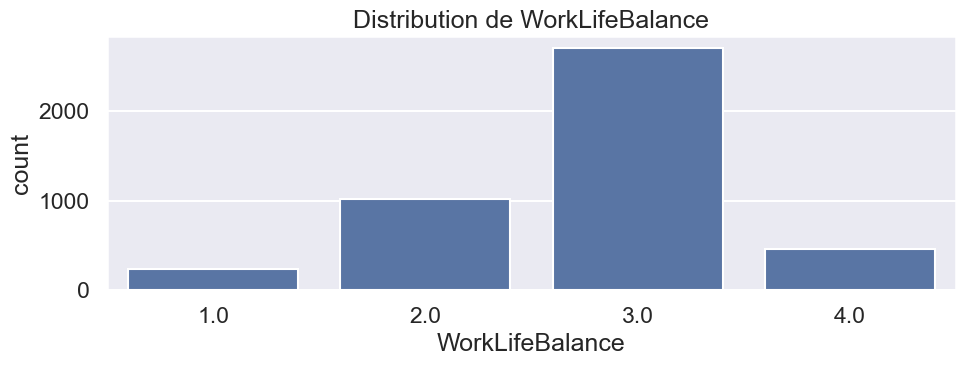

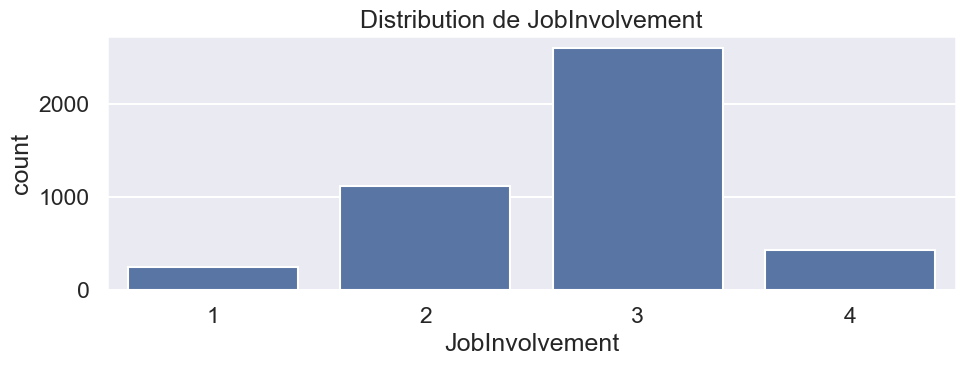

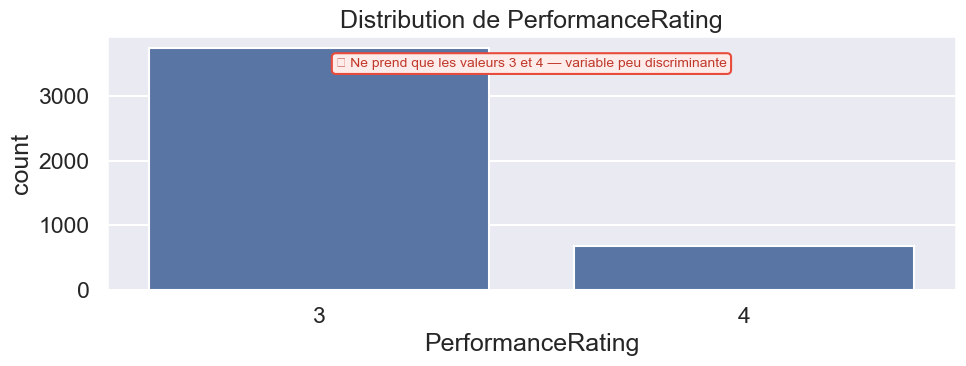

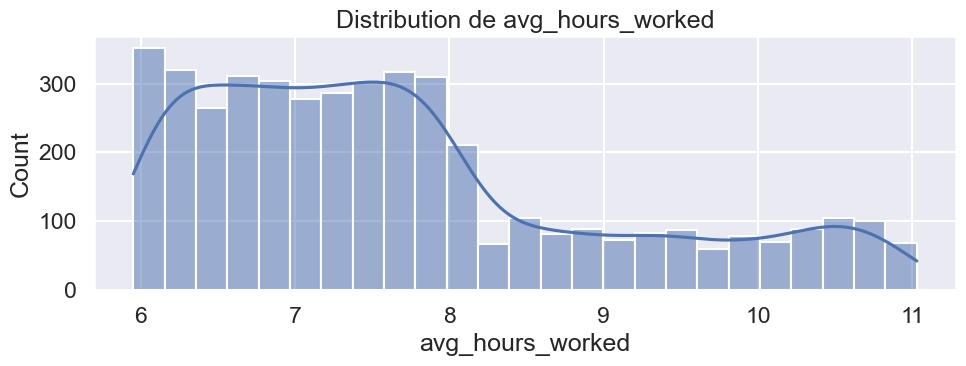

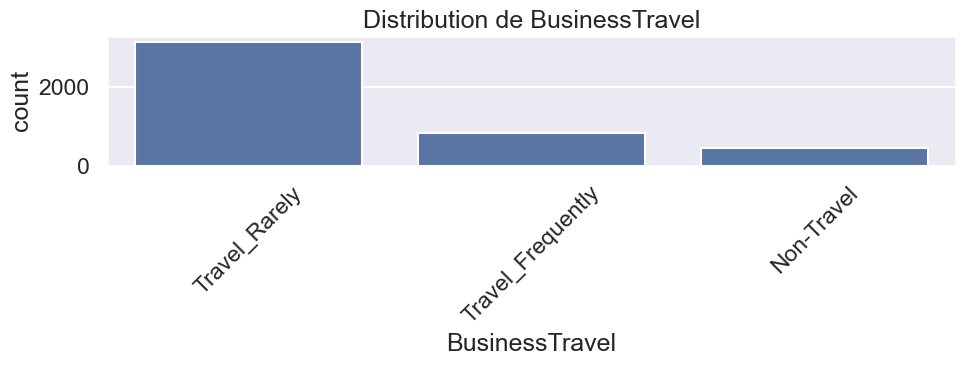

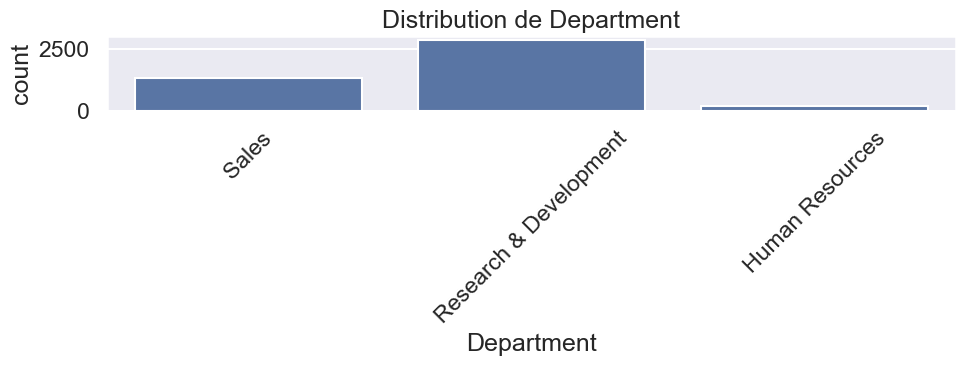

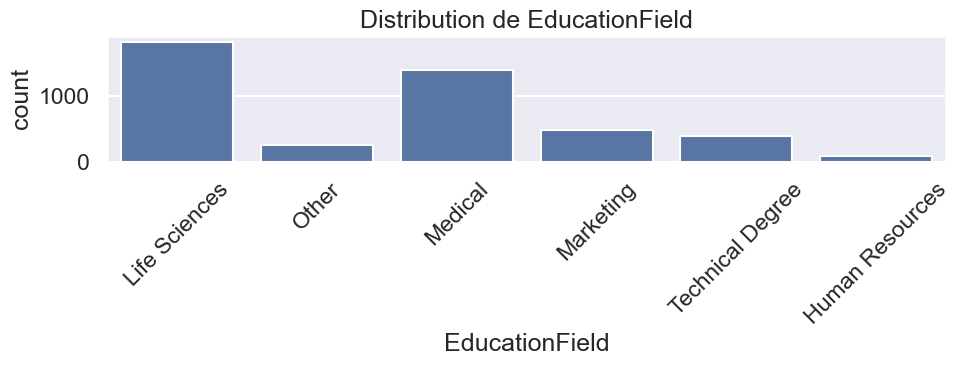

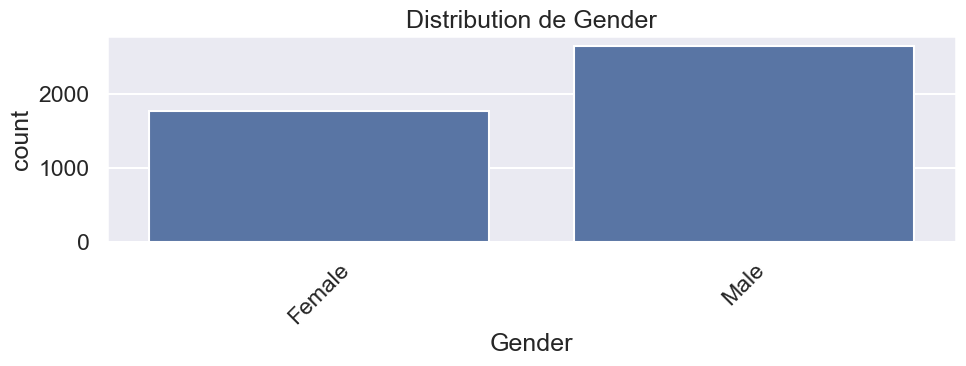

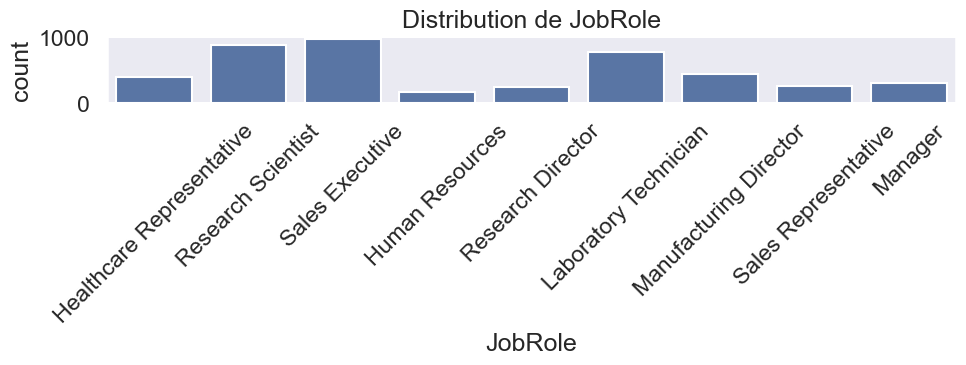

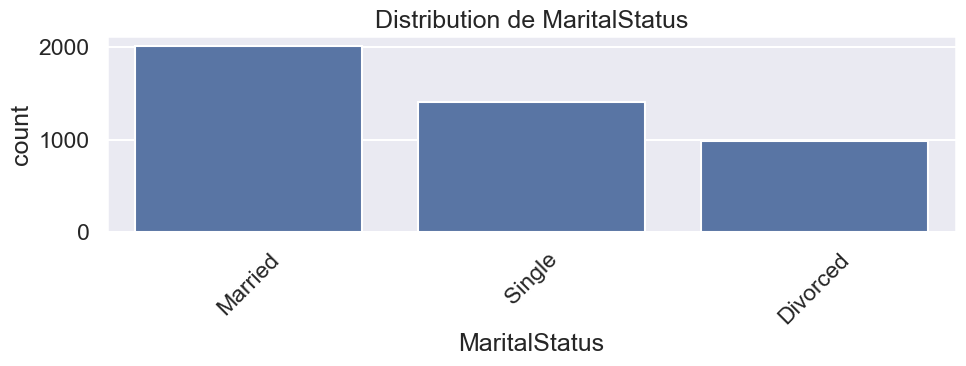

In [8]:
# --- Variables numériques ---
for column in numerical_columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    if employee_data[column].nunique() < 10:
        sns.countplot(x=employee_data[column], ax=ax)
    else:
        sns.histplot(employee_data[column], kde=True, ax=ax)
    ax.set_title(f'Distribution de {column}')
    # Alerte pour PerformanceRating (seulement valeurs 3 et 4)
    if column == 'PerformanceRating':
        ax.text(0.5, 0.88,
                '⚠ Ne prend que les valeurs 3 et 4 — variable peu discriminante',
                transform=ax.transAxes, ha='center', fontsize=10, color='#c0392b',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdecea', edgecolor='#e74c3c'))
    plt.tight_layout()
    plt.show()

# --- Variables catégorielles (hors Attrition) ---
for column in categorical_columns:
    if column == 'Attrition':
        continue
    plt.figure(figsize=(10, 4))
    sns.countplot(x=employee_data[column])
    plt.title(f'Distribution de {column}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 8. Analyse bivariée — Variables vs Attrition

L'analyse bivariée consiste à croiser chaque variable avec la variable cible `Attrition` pour identifier les facteurs les plus discriminants.

**Note éthique (Équité et Non-discrimination) :** 
Certaines variables comme `Gender`, `Age` et `MaritalStatus` sont des critères protégés. Bien qu'elles puissent être statistiquement corrélées à l'attrition, leur utilisation pour des décisions individuelles (ex: ciblage de rétention basé sur le sexe) est **éthiquement problématique et légalement encadrée**. Elles sont conservées ici à des fins de surveillance des biais, mais ne doivent pas constituer des critères de décision automatiques.

- **Variables numériques** : comparaison des distributions via des `boxplots`, validée par un **test de Mann-Whitney U** (test non paramétrique adapté aux distributions non normales).
- **Variables catégorielles** : taux d'attrition par modalité, validé par un **test du Chi²** (indépendance entre la variable et Attrition).

**Lecture :** un p-value < 0.05 indique que la différence observée est statistiquement significative.

Cette étape est centrale pour répondre à la question métier : *quels sont les facteurs ayant le plus d'influence sur le départ des employés ?*

VARIABLES NUMÉRIQUES vs ATTRITION (Mann-Whitney U)


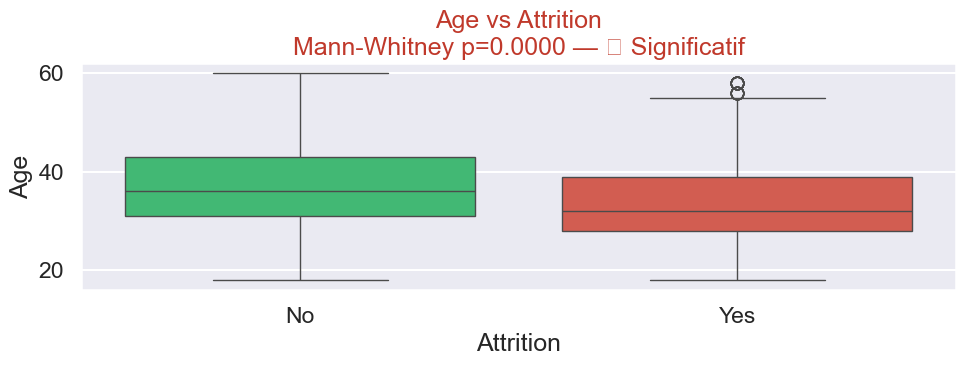

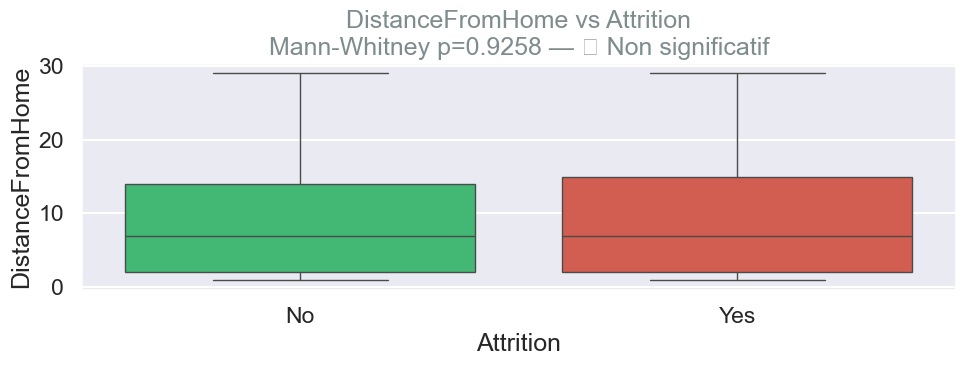

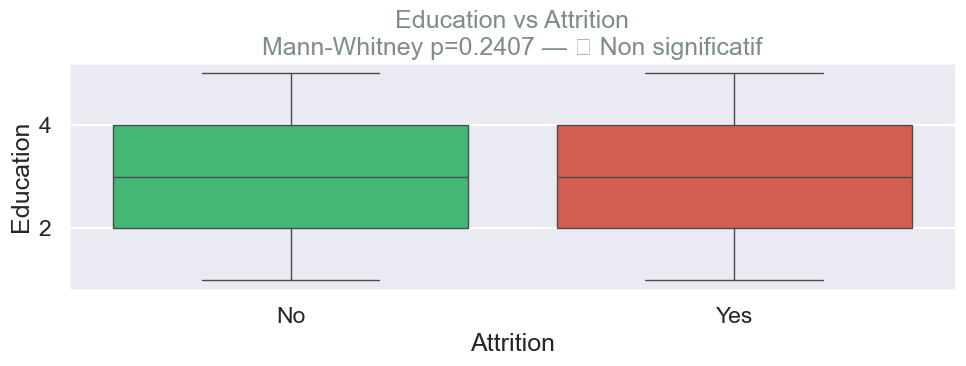

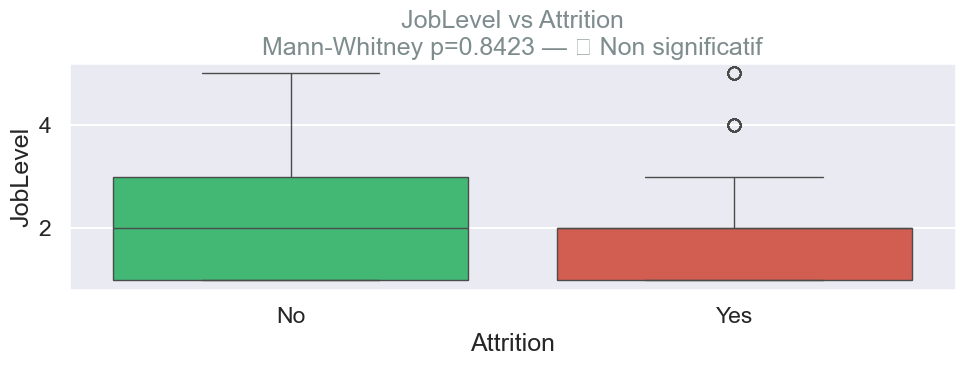

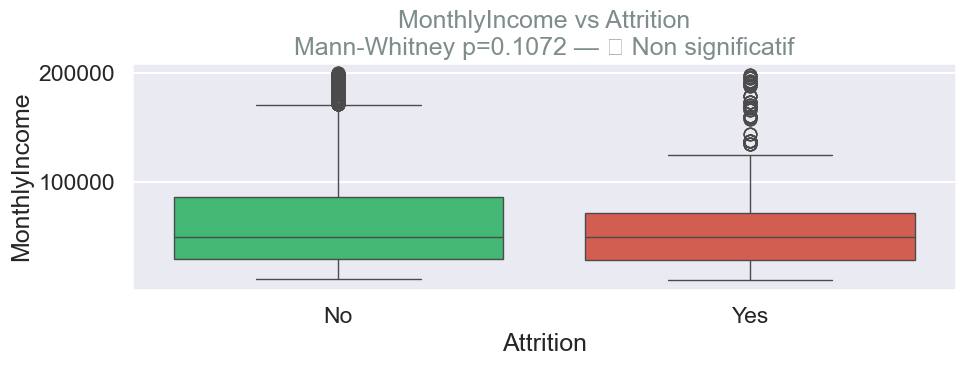

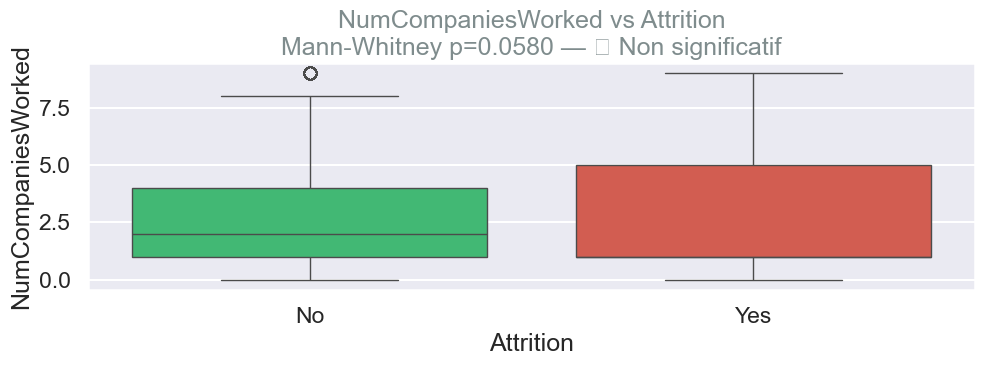

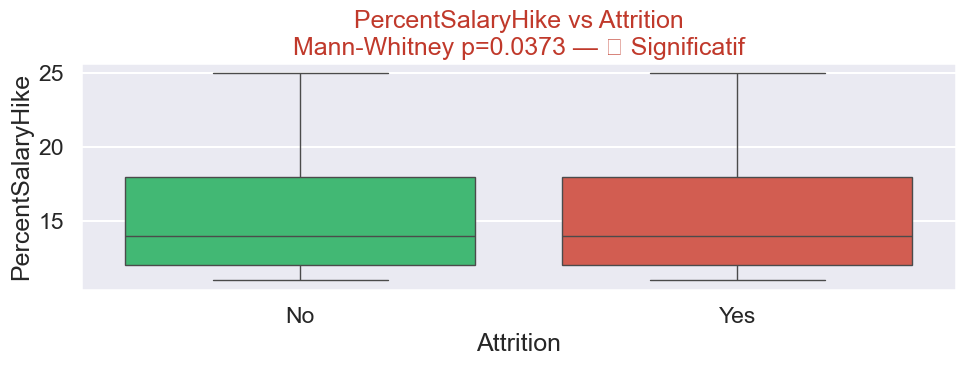

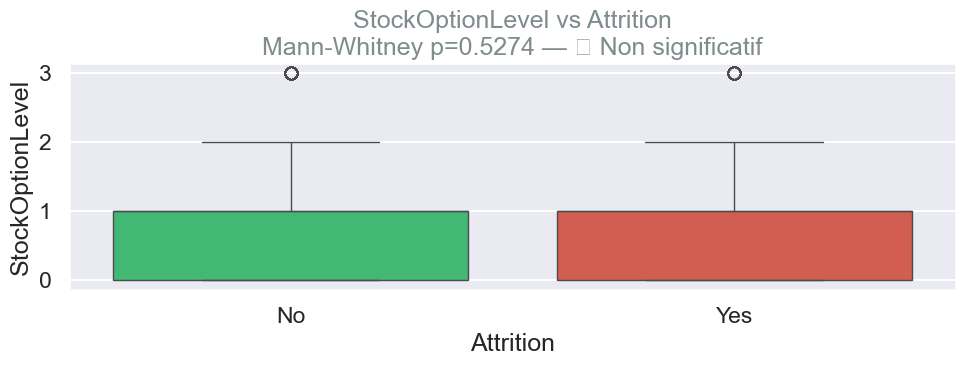

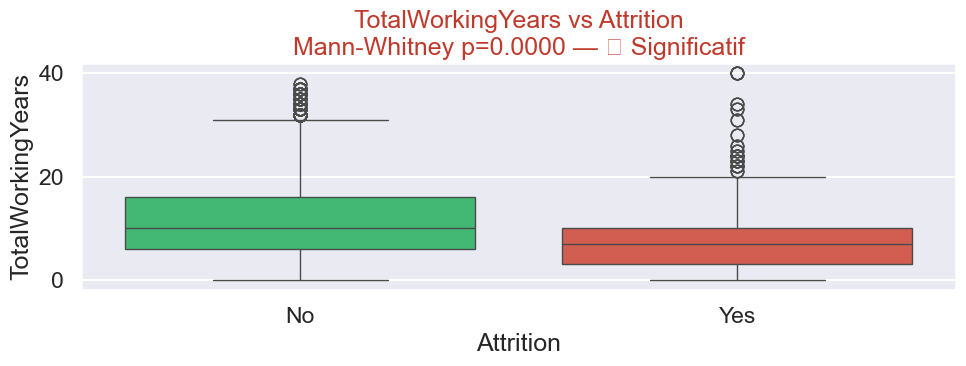

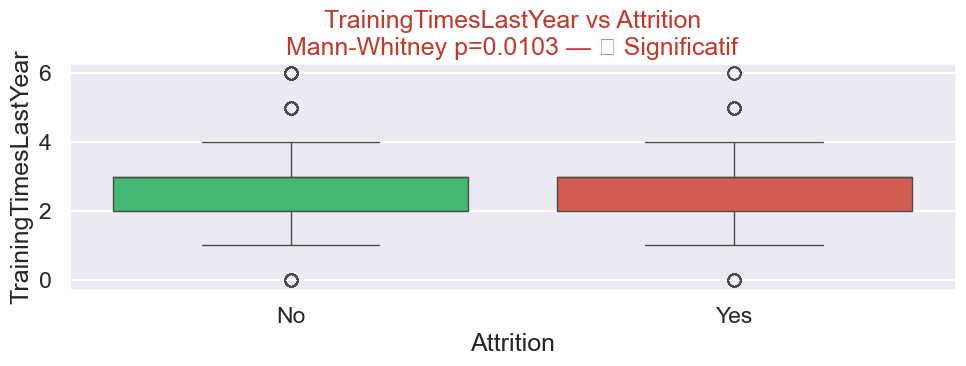

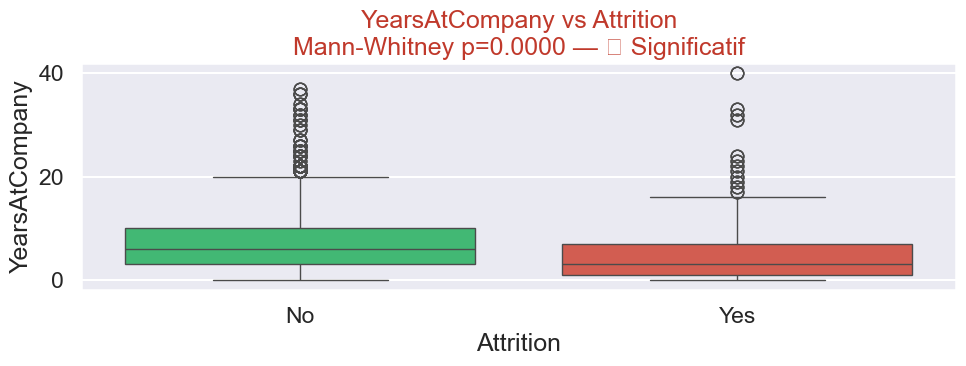

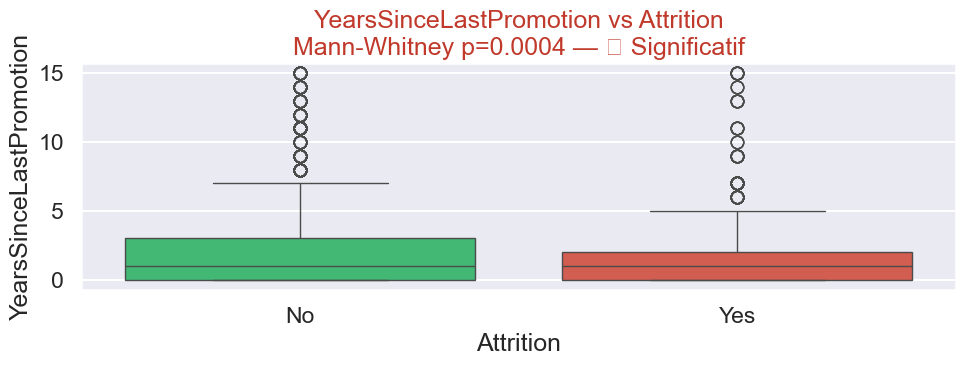

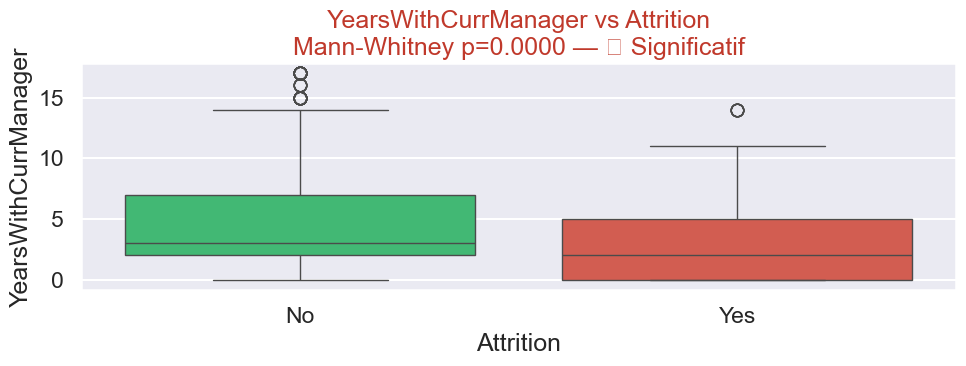

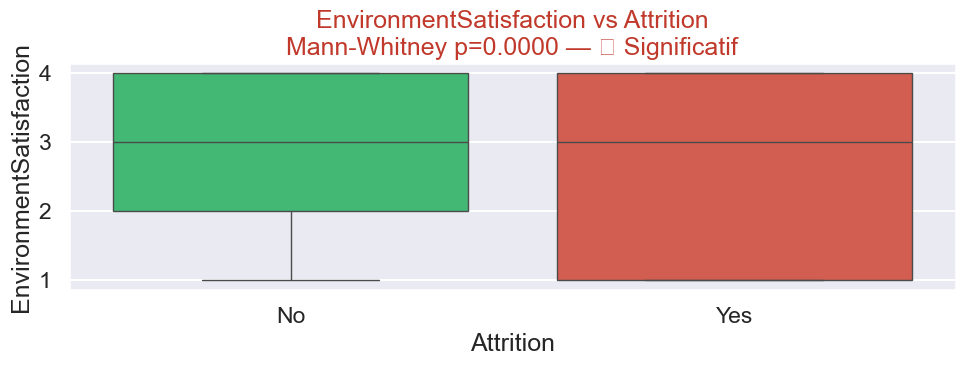

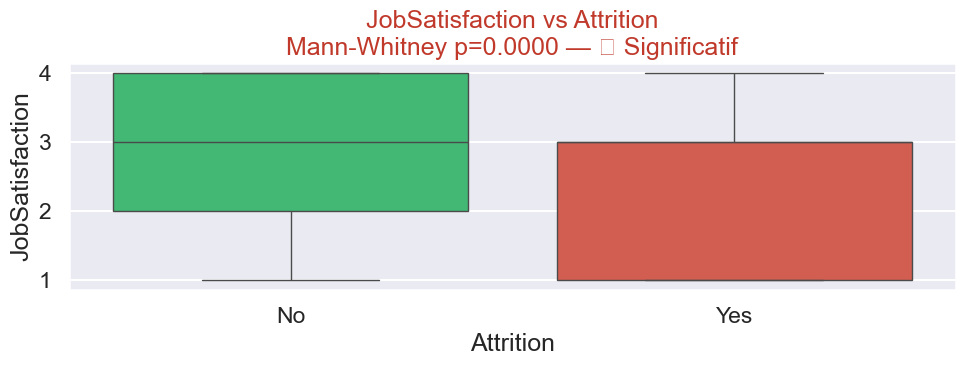

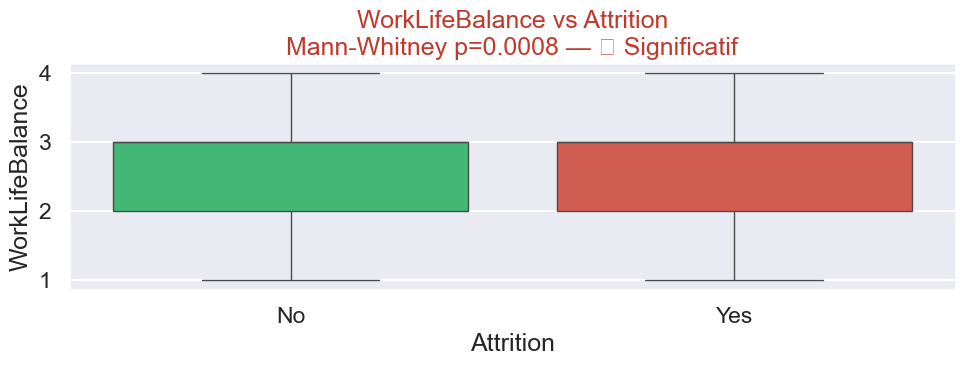

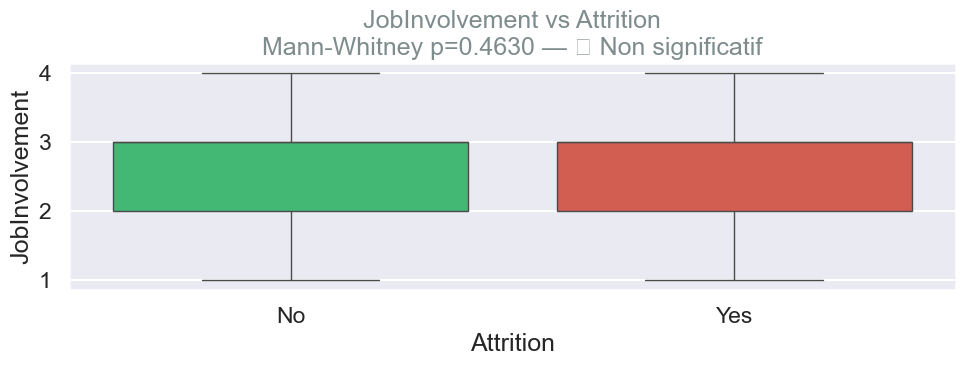

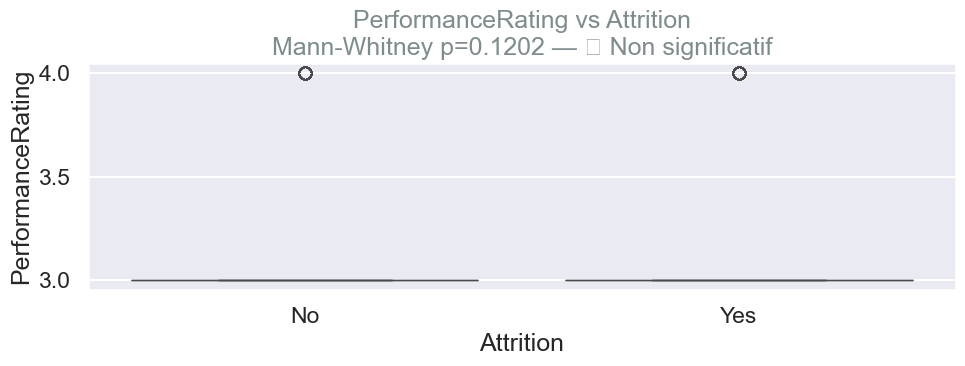

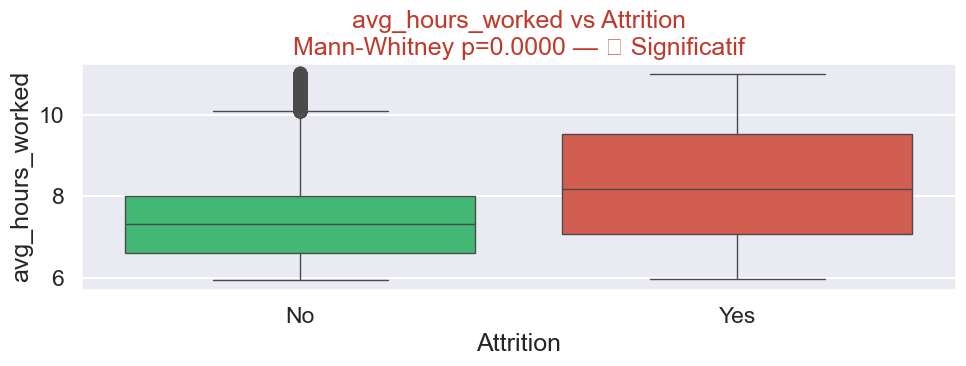


Récapitulatif Mann-Whitney U (trié par p-value) :
               Variable  p-value Significatif (p<0.05)
                    Age     0.00                     ✓
        JobSatisfaction     0.00                     ✓
EnvironmentSatisfaction     0.00                     ✓
   YearsWithCurrManager     0.00                     ✓
         YearsAtCompany     0.00                     ✓
      TotalWorkingYears     0.00                     ✓
       avg_hours_worked     0.00                     ✓
YearsSinceLastPromotion     0.00                     ✓
        WorkLifeBalance     0.00                     ✓
  TrainingTimesLastYear     0.01                     ✓
      PercentSalaryHike     0.04                     ✓
     NumCompaniesWorked     0.06                     ✗
          MonthlyIncome     0.11                     ✗
      PerformanceRating     0.12                     ✗
              Education     0.24                     ✗
         JobInvolvement     0.46                     ✗
       StockOp

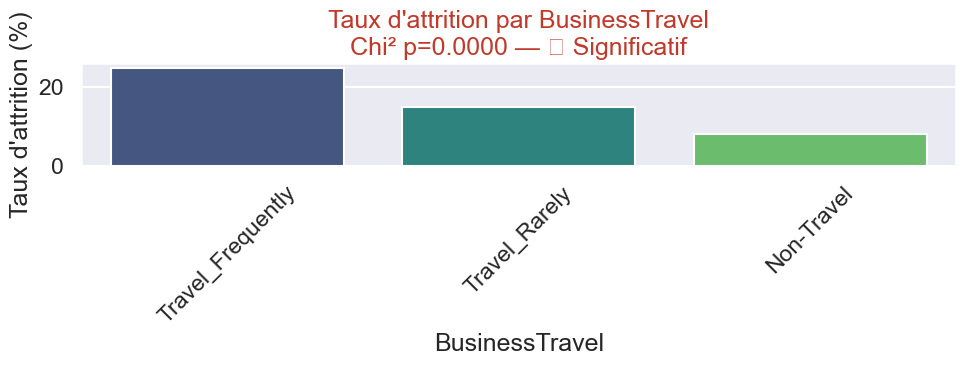

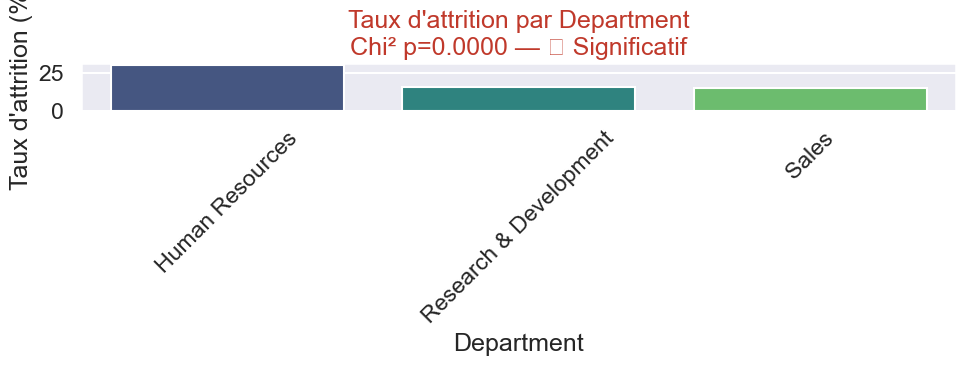

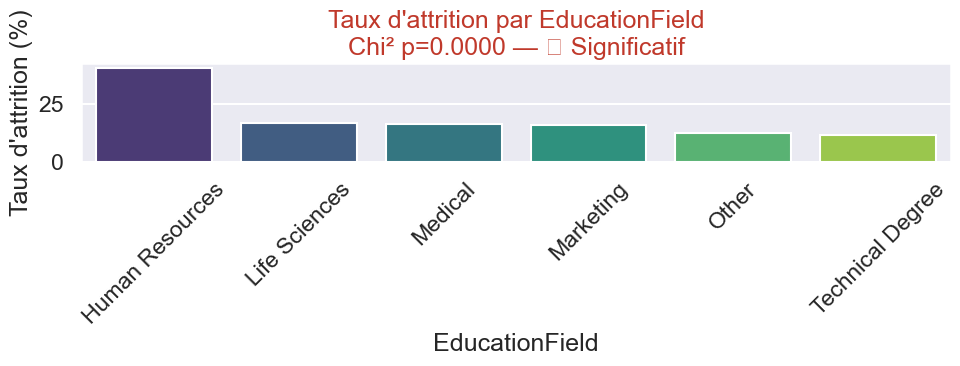

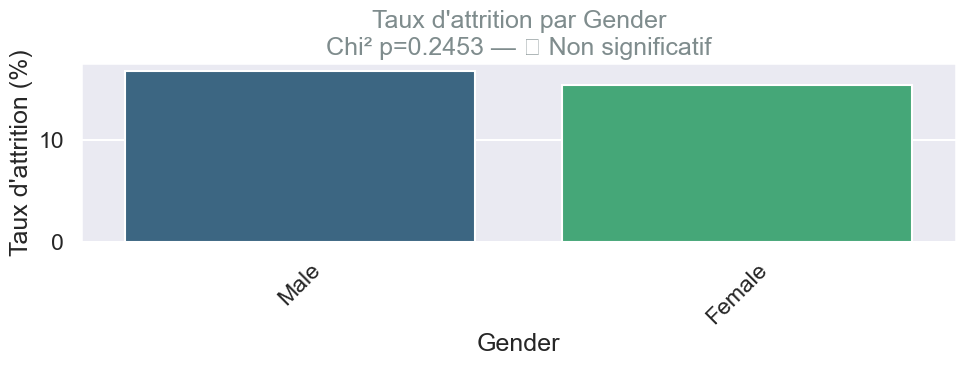

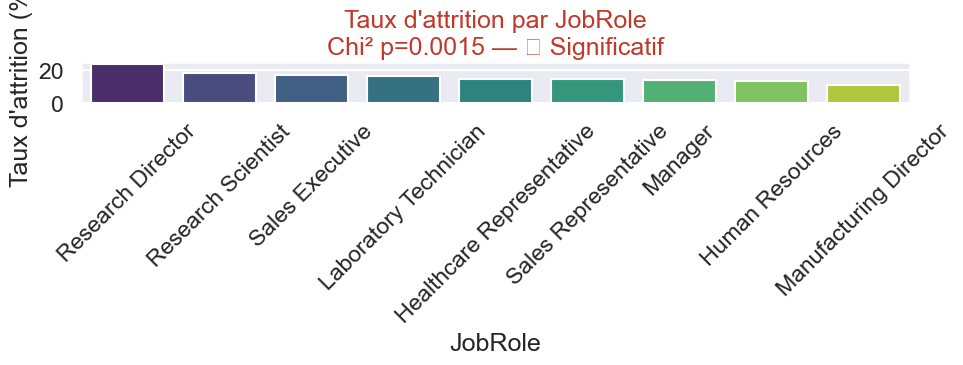

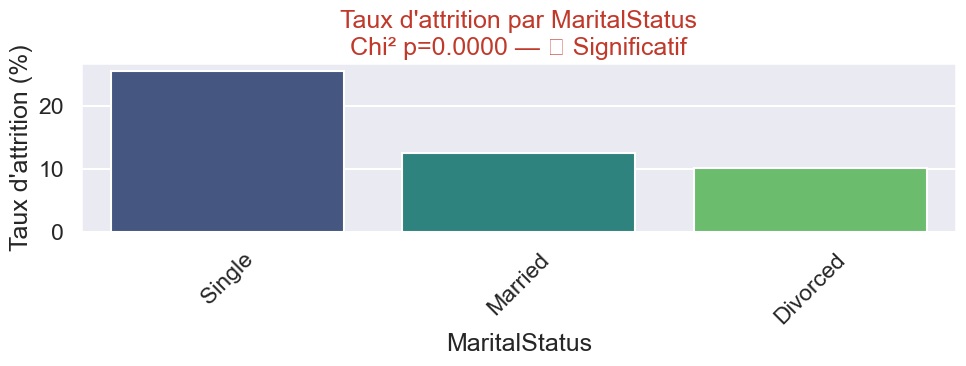


Récapitulatif Chi² (trié par p-value) :
      Variable  p-value Significatif (p<0.05)
BusinessTravel     0.00                     ✓
    Department     0.00                     ✓
EducationField     0.00                     ✓
 MaritalStatus     0.00                     ✓
       JobRole     0.00                     ✓
        Gender     0.25                     ✗


In [9]:
attrition_yes = employee_data[employee_data['Attrition'] == 'Yes']
attrition_no  = employee_data[employee_data['Attrition'] == 'No']

# VARIABLES NUMÉRIQUES vs ATTRITION — Boxplot + Mann-Whitney U
print('VARIABLES NUMÉRIQUES vs ATTRITION (Mann-Whitney U)')

results_num = []
for column in numerical_columns:
    stat, p_val = stats.mannwhitneyu(
        attrition_yes[column].dropna(),
        attrition_no[column].dropna(),
        alternative='two-sided'
    )
    significance = '✓ Significatif' if p_val < 0.05 else '✗ Non significatif'
    color_title  = '#c0392b' if p_val < 0.05 else '#7f8c8d'

    plt.figure(figsize=(10, 4))
    sns.boxplot(x='Attrition', y=column, data=employee_data,
                palette=['#2ecc71', '#e74c3c'])
    plt.title(f'{column} vs Attrition\nMann-Whitney p={p_val:.4f} — {significance}',
              color=color_title)
    plt.tight_layout()
    plt.show()

    results_num.append({
        'Variable': column,
        'p-value': round(p_val, 4),
        'Significatif (p<0.05)': '✓' if p_val < 0.05 else '✗'
    })

df_results_num = pd.DataFrame(results_num).sort_values('p-value')
print('\nRécapitulatif Mann-Whitney U (trié par p-value) :')
print(df_results_num.to_string(index=False))

# VARIABLES CATÉGORIELLES vs ATTRITION — Taux d'attrition + Chi²
print('VARIABLES CATÉGORIELLES vs ATTRITION (Chi²)')

results_cat = []
for column in categorical_columns:
    if column == 'Attrition':
        continue

    attrition_rate = employee_data.groupby(column)['Attrition'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    attrition_rate.columns = [column, "Taux d'attrition (%)"]
    attrition_rate = attrition_rate.sort_values("Taux d'attrition (%)", ascending=False)

    contingency = pd.crosstab(employee_data[column], employee_data['Attrition'])
    chi2, p_val, _, _ = stats.chi2_contingency(contingency)
    significance = '✓ Significatif' if p_val < 0.05 else '✗ Non significatif'
    color_title  = '#c0392b' if p_val < 0.05 else '#7f8c8d'

    plt.figure(figsize=(10, 4))
    sns.barplot(x=column, y="Taux d'attrition (%)", data=attrition_rate, palette='viridis')
    plt.title(f"Taux d'attrition par {column}\nChi² p={p_val:.4f} — {significance}",
              color=color_title)
    plt.xticks(rotation=45)
    plt.ylabel("Taux d'attrition (%)")
    plt.tight_layout()
    plt.show()

    results_cat.append({
        'Variable': column,
        'p-value': round(p_val, 4),
        'Significatif (p<0.05)': '✓' if p_val < 0.05 else '✗'
    })

df_results_cat = pd.DataFrame(results_cat).sort_values('p-value')
print('\nRécapitulatif Chi² (trié par p-value) :')
print(df_results_cat.to_string(index=False))

## 9. Analyse dédiée — Heures travaillées vs Attrition

La variable `avg_hours_worked`, issue du feature engineering sur les fichiers de badgeage, mérite une analyse visuelle approfondie.

On cherche à valider l'hypothèse suivante : **les employés qui travaillent davantage sont-ils plus susceptibles de quitter l'entreprise ?**

On combine un boxplot (comparaison des médianes) et un graphe de densité KDE (visualisation complète des distributions par groupe).

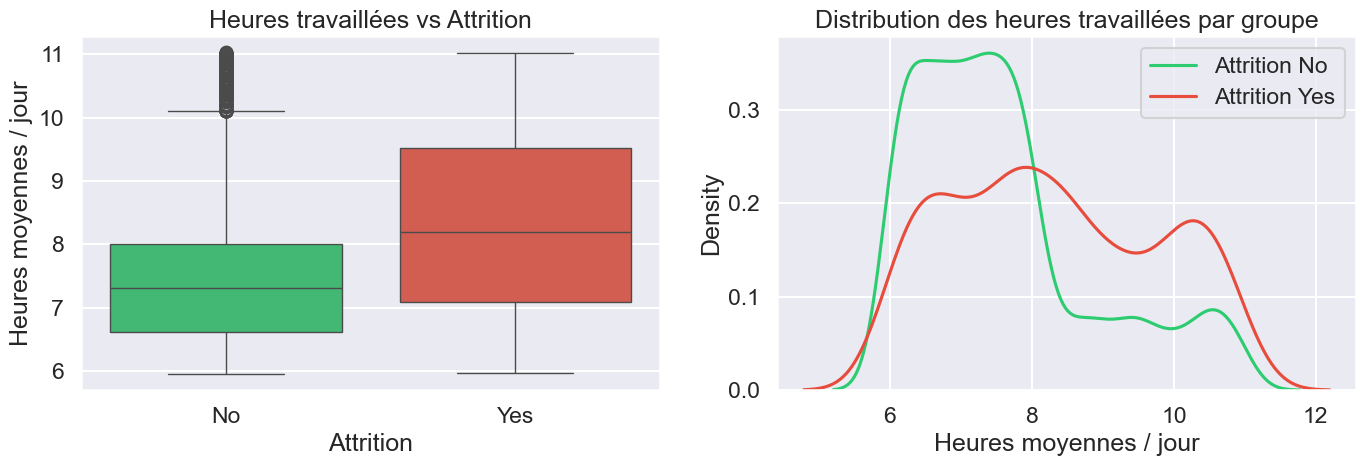

Statistiques heures travaillées par groupe :
            count  mean  std  min  25%  50%  75%   max
Attrition                                             
No        3699.00  7.58 1.28 5.95 6.61 7.31 8.00 11.03
Yes        711.00  8.32 1.46 5.96 7.09 8.19 9.53 11.02


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(x='Attrition', y='avg_hours_worked', data=employee_data,
            palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Heures travaillées vs Attrition')
axes[0].set_ylabel('Heures moyennes / jour')

# Distribution KDE par groupe
for label, color in zip(['No', 'Yes'], ['#2ecc71', '#e74c3c']):
    subset = employee_data[employee_data['Attrition'] == label]['avg_hours_worked']
    sns.kdeplot(subset, label=f'Attrition {label}', color=color, ax=axes[1])
axes[1].set_title('Distribution des heures travaillées par groupe')
axes[1].set_xlabel('Heures moyennes / jour')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Statistiques heures travaillées par groupe :')
print(employee_data.groupby('Attrition')['avg_hours_worked'].describe().round(2))

## 10. Matrice de corrélation

La heatmap de corrélation permet de visualiser les relations linéaires entre toutes les variables numériques.

Elle permet d'identifier :
- Les variables **fortement corrélées entre elles** (risque de multicolinéarité)
- Les variables **les plus corrélées à `Attrition`** (après encodage binaire : `Yes` → 1, `No` → 0)

> **Rappel :** la corrélation mesure uniquement les relations **linéaires**. Une corrélation faible ne signifie pas absence de relation non linéaire.

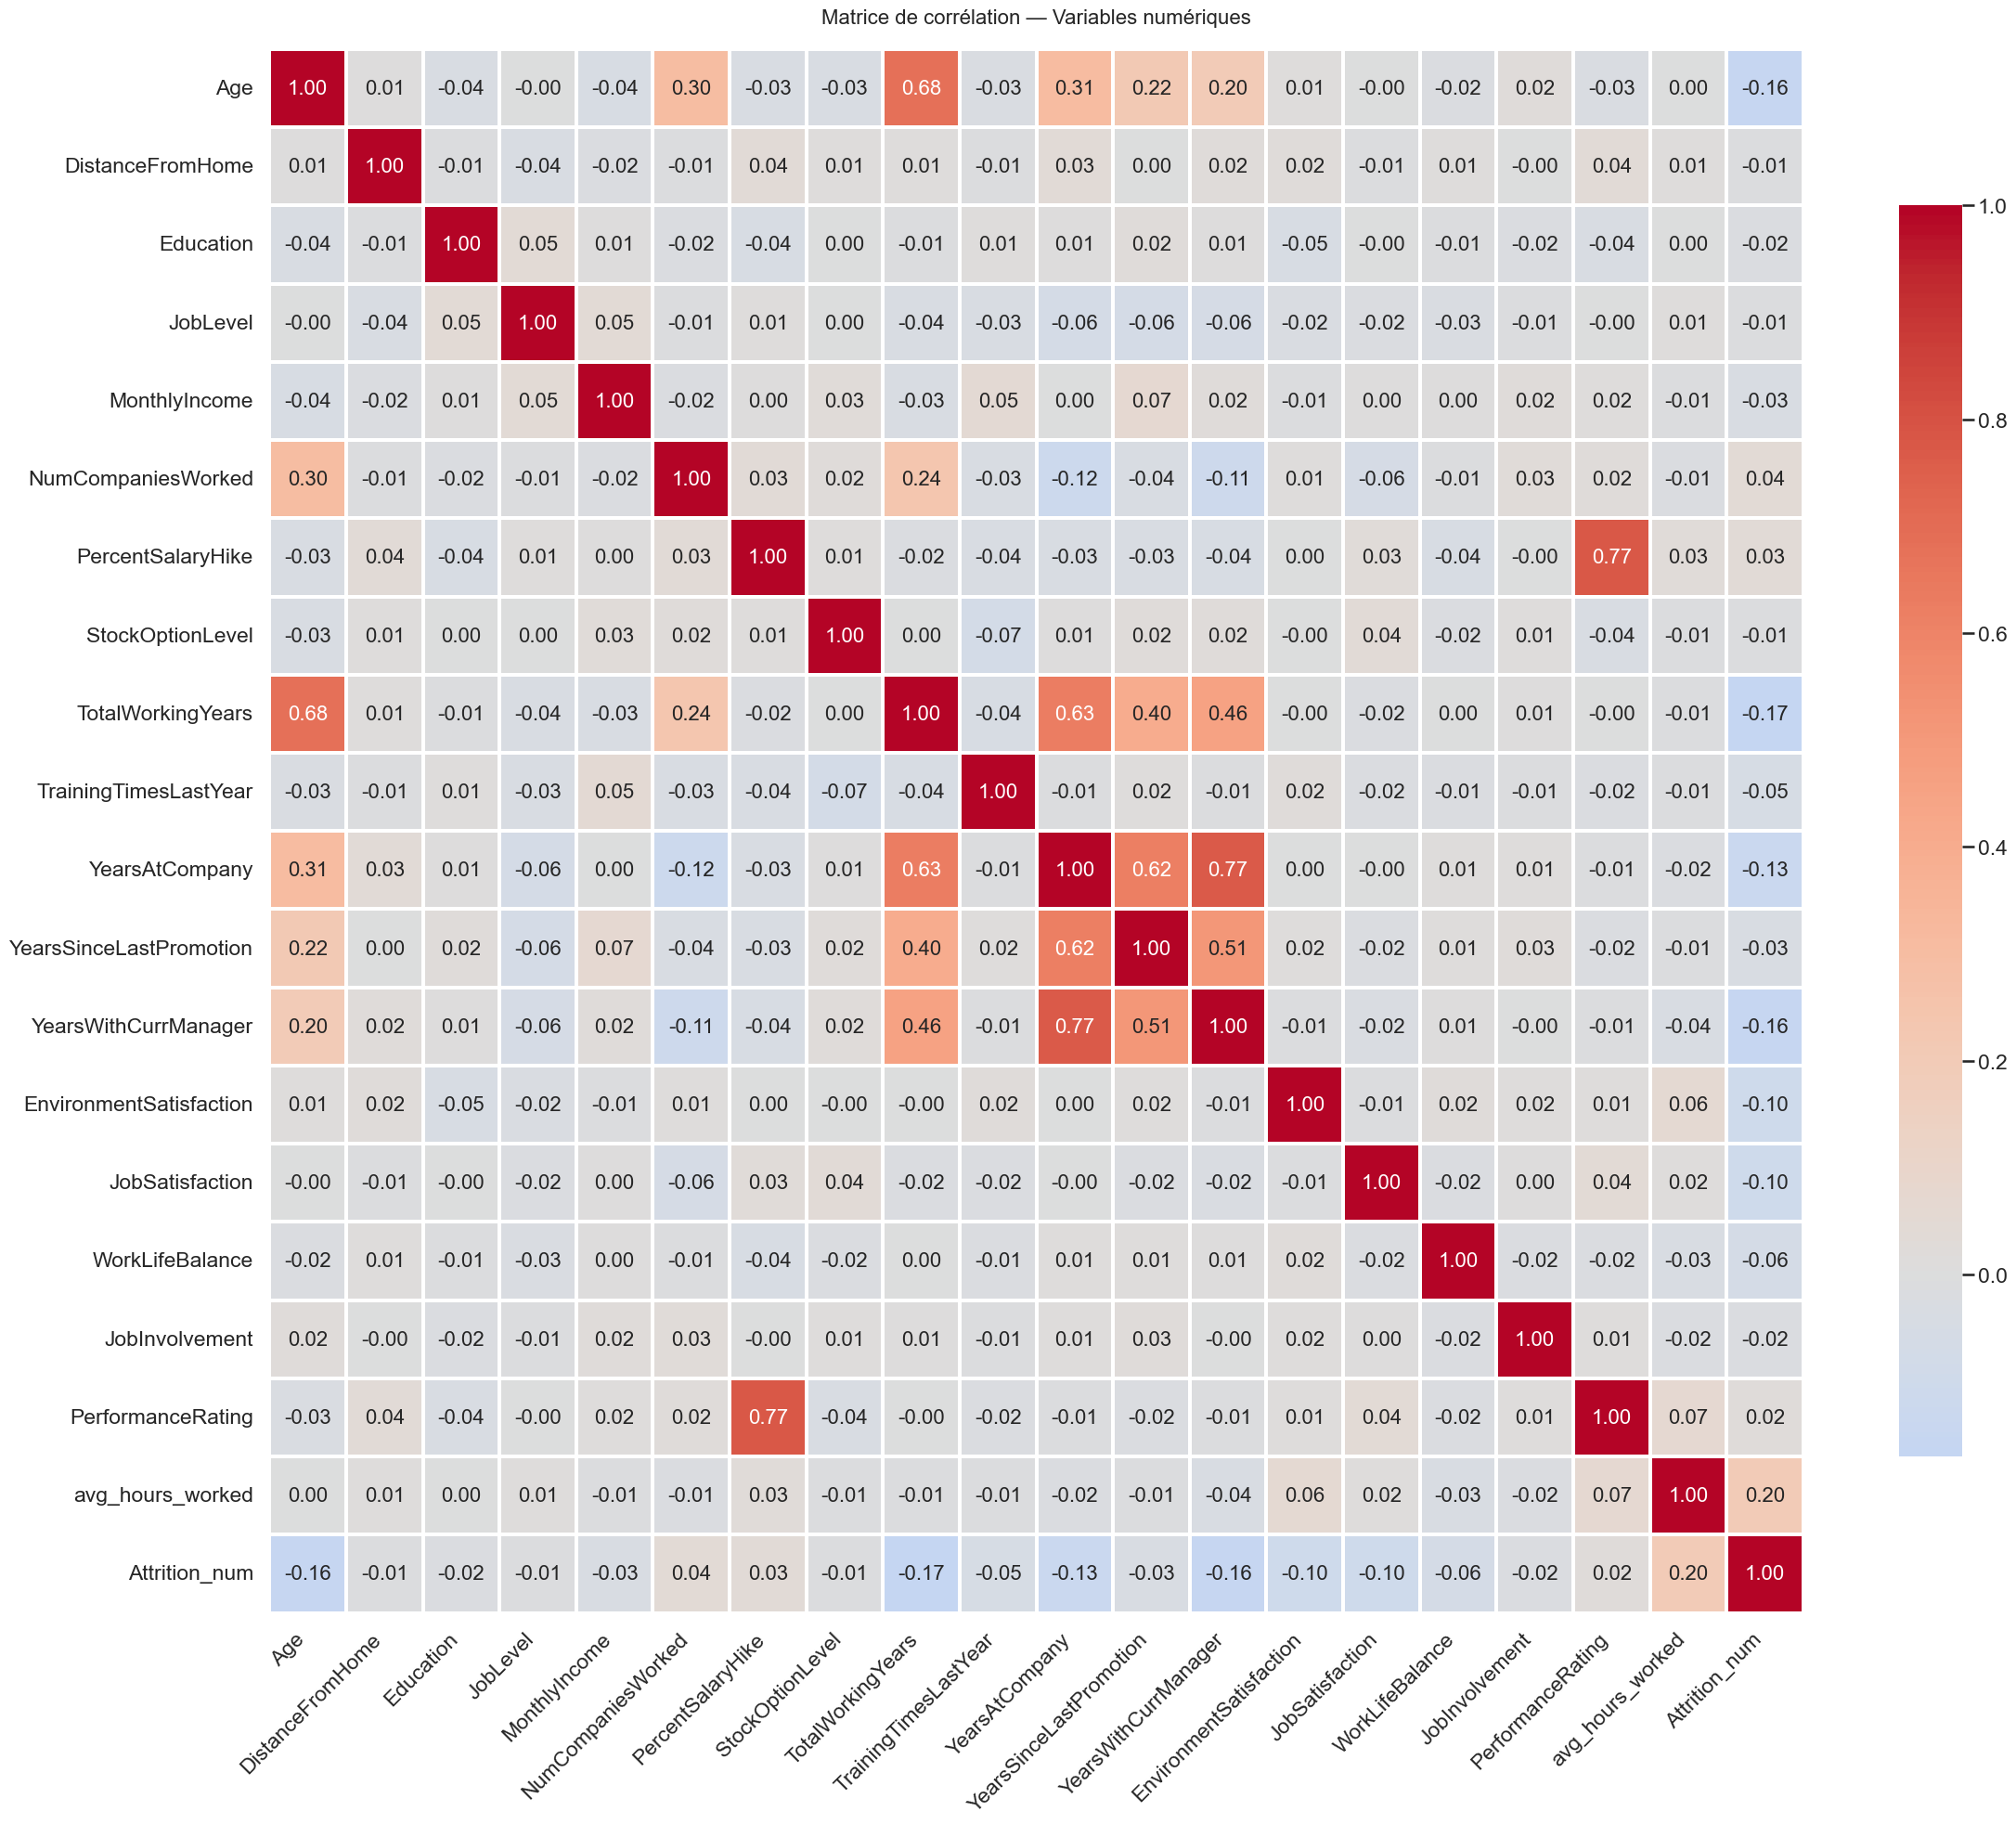

Corrélations avec Attrition (triées par valeur absolue) :
avg_hours_worked           0.20
TotalWorkingYears         -0.17
Age                       -0.16
YearsWithCurrManager      -0.16
YearsAtCompany            -0.13
JobSatisfaction           -0.10
EnvironmentSatisfaction   -0.10
WorkLifeBalance           -0.06
TrainingTimesLastYear     -0.05
NumCompaniesWorked         0.04
YearsSinceLastPromotion   -0.03
PercentSalaryHike          0.03
MonthlyIncome             -0.03
PerformanceRating          0.02
JobInvolvement            -0.02
Education                 -0.02
JobLevel                  -0.01
DistanceFromHome          -0.01
StockOptionLevel          -0.01
Name: Attrition_num, dtype: float64


In [11]:
corr_data = employee_data.copy()
corr_data['Attrition_num'] = corr_data['Attrition'].map({'Yes': 1, 'No': 0})

corr_cols   = [c for c in numerical_columns + ['Attrition_num'] if c in corr_data.columns]
corr_matrix = corr_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(24, 20))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=1.5,
    cbar_kws={'shrink': 0.8},
    ax=ax,
    annot_kws={'size': 16}
)
ax.set_title('Matrice de corrélation — Variables numériques', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print('Corrélations avec Attrition (triées par valeur absolue) :')
print(corr_matrix['Attrition_num'].drop('Attrition_num').sort_values(key=abs, ascending=False))

## 11. Conclusion de l'analyse exploratoire

L'analyse exploratoire a permis d'identifier les principaux facteurs associés à l'attrition des employés chez HumanForYou. Les tests statistiques (Mann-Whitney U et Chi²) confirment la significativité de la majorité des relations observées.

---

### Facteurs numériques significatifs

- **Charge de travail élevée** (`avg_hours_worked`) : les employés qui travaillent le plus d'heures sont proportionnellement plus nombreux à quitter l'entreprise — lien entre surcharge et désengagement.
- **Profil junior** (`TotalWorkingYears`, `Age`) : les employés jeunes avec peu d'ancienneté globale sont plus susceptibles de partir — mobilité professionnelle en début de carrière.
- **Relation avec le manager** (`YearsWithCurrManager`) : une longue collaboration avec le manager actuel est associée à une plus grande fidélité — la stabilité managériale est un facteur de rétention.
- **Satisfaction au travail** (`JobSatisfaction`, `EnvironmentSatisfaction`) : les employés insatisfaits de leur poste ou de leur environnement partent davantage.

### Facteurs catégoriels significatifs

- **Statut marital** (`MaritalStatus`) : les célibataires présentent un taux d'attrition nettement plus élevé — moins d'attaches géographiques ou familiales.
- **Fréquence des déplacements** (`BusinessTravel`) : les employés qui voyagent fréquemment (`Travel_Frequently`) quittent bien plus l'entreprise — fatigue liée aux contraintes de mobilité.
- **Métier** (`JobRole`) : certains postes (Sales Representative notamment) affichent des taux d'attrition structurellement plus élevés que d'autres rôles.

---

### Points de vigilance pour la modélisation

| Point | Détail |
|---|---|
| **Déséquilibre de classes** | ~84% No / ~16% Yes → appliquer SMOTE ou class_weight |
| **Multicolinéarité** | `Age`, `TotalWorkingYears`, `YearsAtCompany` fortement corrélées entre elles |
| **Variable peu discriminante** | `PerformanceRating` ne prend que les valeurs 3 et 4 → à considérer pour suppression |
| **Non-linéarité** | Certaines relations sont non linéaires — Random Forest ou XGBoost pourront mieux les capturer ? |

---

> Ces observations orienteront le choix des variables et des algorithmes dans la phase de modélisation.

## 12. Standardisation et Normalisation des données

Avant d'appliquer un algorithme de clustering comme K-Means, il est indispensable de mettre toutes les variables numériques à la même échelle. Sans cette étape, les variables avec de grandes amplitudes (ex: salaire) domineraient le calcul des distances.

Deux approches sont utilisées ici :
- **Standardisation (StandardScaler)** : centre les données autour de 0 avec un écart-type de 1. Recommandée quand les données suivent approximativement une distribution normale.
- **Normalisation (MinMaxScaler)** : ramène les valeurs entre 0 et 1. Utile quand on veut conserver la forme de la distribution originale.

Pour K-Means, on utilisera la **standardisation** qui est généralement préférable.

In [12]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Sélection des colonnes numériques pertinentes pour le clustering
# On exclut les colonnes sans variance réelle ou non pertinentes
cols_to_exclude = ['EmployeeID', 'EmployeeCount', 'StandardHours', 'Over18']
cluster_features = [col for col in numerical_columns if col not in cols_to_exclude]

# Encodage de la variable Attrition pour éventuellement l'inclure
df_cluster = employee_data[cluster_features].copy()

# --- Standardisation ---
scaler_standard = StandardScaler()
df_standardized = pd.DataFrame(
    scaler_standard.fit_transform(df_cluster),
    columns=cluster_features
)

# --- Normalisation ---
scaler_minmax = MinMaxScaler()
df_normalized = pd.DataFrame(
    scaler_minmax.fit_transform(df_cluster),
    columns=cluster_features
)

## 13. Clustering avec K-Means

K-Means est un algorithme de clustering non supervisé qui partitionne les données en **K groupes** en minimisant la variance intra-cluster (inertie).

**Étapes :**
1. **Méthode du coude (Elbow Method)** : on entraîne K-Means pour différentes valeurs de K et on trace l'inertie. Le "coude" de la courbe indique le K optimal.
2. **Score de silhouette** : mesure la cohésion et la séparation des clusters (plus proche de 1 = meilleur).
3. **Entraînement final** avec le K optimal.
4. **Analyse des clusters** : profil moyen de chaque cluster et taux d'attrition associé.

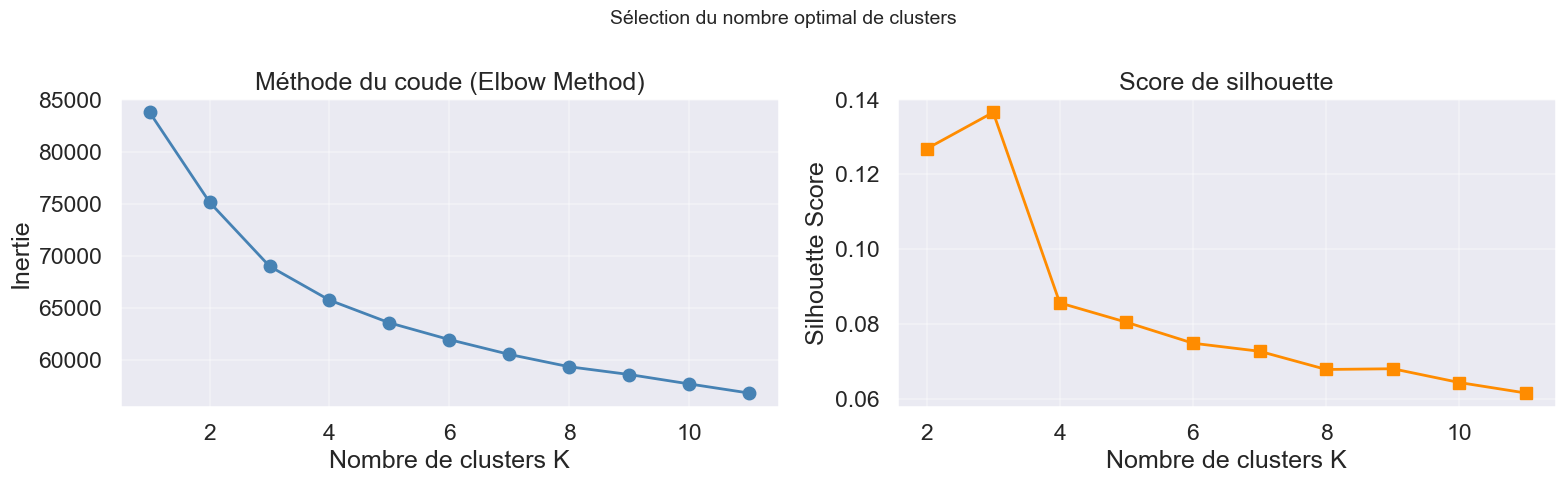

K optimal selon le score de silhouette : 3

Profil moyen par cluster :


Cluster,0,1,2
Age,35.68,42.52,35.14
DistanceFromHome,9.79,9.66,8.88
Education,2.81,2.92,2.94
JobLevel,2.07,1.88,2.13
MonthlyIncome,66468.69,67660.38,63716.44
NumCompaniesWorked,2.82,2.60,2.69
PercentSalaryHike,21.86,14.04,14.09
StockOptionLevel,0.71,0.78,0.82
TotalWorkingYears,10.33,19.27,8.53
TrainingTimesLastYear,2.69,2.78,2.83


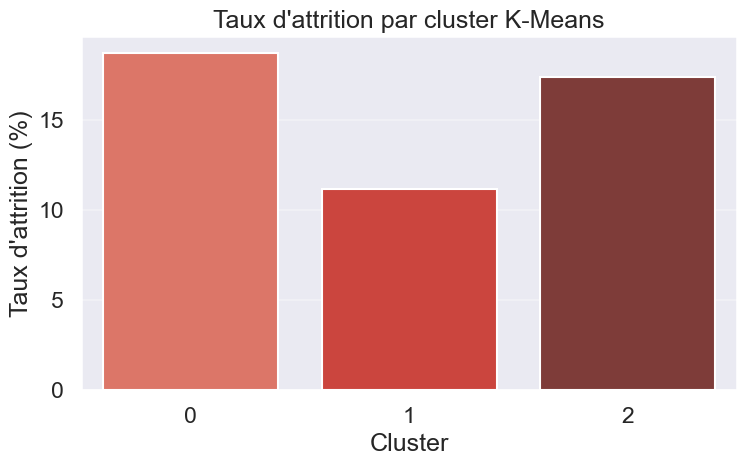


Répartition des employés par cluster :
Cluster
0     642
1    1020
2    2748
Name: count, dtype: int64


In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# On travaille sur les données standardisées
X = df_standardized.values

# 1. Méthode du coude + Score de silhouette 
inertias        = []
silhouette_scores = []
K_range = range(1, 12) 
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)
    if k >= 2:
        silhouette_scores.append(silhouette_score(X, km.labels_))
    else:
        silhouette_scores.append(None) 

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Méthode du coude (Elbow Method)')
axes[0].set_xlabel('Nombre de clusters K')
axes[0].set_ylabel('Inertie')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, marker='s', color='darkorange', linewidth=2)
axes[1].set_title('Score de silhouette')
axes[1].set_xlabel('Nombre de clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Sélection du nombre optimal de clusters', fontsize=14)
plt.tight_layout()
plt.show()

# 2. Entraînement final avec le K optimal 
K_OPTIMAL = max(zip(K_range, silhouette_scores), key=lambda x: x[1] if x[1] is not None else -1)[0]
print(f"K optimal selon le score de silhouette : {K_OPTIMAL}")

kmeans_final = KMeans(n_clusters=K_OPTIMAL, init='k-means++', n_init=10, random_state=42)
kmeans_final.fit(X)

employee_data['Cluster'] = kmeans_final.labels_

# 3. Profil moyen de chaque cluster
cluster_profile = employee_data.groupby('Cluster')[cluster_features].mean()
print("\nProfil moyen par cluster :")
display(cluster_profile.T)

# 4. Taux d'attrition par cluster 
attrition_by_cluster = employee_data.groupby('Cluster')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
attrition_by_cluster.columns = ['Cluster', 'Attrition_Rate (%)']

plt.figure(figsize=(8, 5))
sns.barplot(data=attrition_by_cluster, x='Cluster', y='Attrition_Rate (%)',
            palette='Reds_d')
plt.title("Taux d'attrition par cluster K-Means")
plt.ylabel("Taux d'attrition (%)")
plt.xlabel("Cluster")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Taille des clusters
print("\nRépartition des employés par cluster :")
print(employee_data['Cluster'].value_counts().sort_index())

## 15. Préparation à la modélisation supervisée


In [14]:
from sklearn.model_selection import train_test_split

# --- 14.1 Encodage de la cible ---
# Attrition : 'Yes' → 1, 'No' → 0
df_model = employee_data.copy()
df_model['Attrition'] = df_model['Attrition'].map({'Yes': 1, 'No': 0})

# Note éthique : Exclusion des variables discriminatoires
# Bien que corrélées statistiquement, ces variables sont des critères protégés.
# Pour garantir l'équité du modèle et éviter des biais de décision, on les retire des features.
df_model = df_model.drop(columns=['Gender', 'MaritalStatus'])

# Vérification du ratio des classes
print("Distribution de la cible :")
print(df_model['Attrition'].value_counts(normalize=True).round(3) * 100)
print()

# --- 14.2 Suppression des colonnes non-prédictives ---
# 'Cluster' est issu du K-Means (non supervisé) → ne doit pas être une feature
cols_to_drop = ['Cluster'] if 'Cluster' in df_model.columns else []
df_model = df_model.drop(columns=cols_to_drop)

# --- 14.3 Encodage One-Hot des variables catégorielles ---
# drop_first=True évite la multicolinéarité (dummy variable trap)
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Attrition') if 'Attrition' in categorical_cols else None
print(f"Variables catégorielles encodées : {categorical_cols}")

df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
print(f"\nShape après encodage : {df_encoded.shape}")

# --- 14.4 Séparation X / y ---
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

# --- 14.5 Train/Test split stratifié ---
# stratify=y garantit le même ratio d'attrition dans train et test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTaille train : {X_train.shape[0]} lignes ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Taille test  : {X_test.shape[0]} lignes ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nRatio attrition dans train : {y_train.mean()*100:.1f}%")
print(f"Ratio attrition dans test  : {y_test.mean()*100:.1f}%")

Distribution de la cible :
Attrition
0   83.90
1   16.10
Name: proportion, dtype: float64

Variables catégorielles encodées : ['BusinessTravel', 'Department', 'EducationField', 'JobRole']

Shape après encodage : (4410, 37)

Taille train : 3528 lignes (80%)
Taille test  : 882 lignes (20%)

Ratio attrition dans train : 16.1%
Ratio attrition dans test  : 16.1%


## 15. Modélisation — Régression Logistique

### Pourquoi la régression logistique ?
- **Cible binaire** (Yes/No) → modèle de classification adapté.
- **Interprétabilité** : les coefficients permettent de comprendre l'effet de chaque variable sur la probabilité d'attrition, ce qui est cohérent avec notre analyse bivariée.
- **Référence solide** : c'est le modèle de base en classification supervisée, idéal avant de tester des modèles plus complexes.

### Gestion du déséquilibre de classes
Le paramètre `class_weight='balanced'` ajuste automatiquement les poids des classes en fonction de leur fréquence :
- La classe minoritaire (Yes = 16%) reçoit un poids plus élevé
- Le modèle ne sera pas biaisé vers la prédiction systématique de "No"

### Métriques d'évaluation
- **Matrice de confusion** : visualise les vrais/faux positifs et négatifs
- **F1-score** : équilibre précision et rappel — adapté aux classes déséquilibrées
- **AUC-ROC** : mesure la capacité du modèle à discriminer les deux classes (0.5 = aléatoire, 1.0 = parfait)
- **Recall (sensibilité)** : prioritaire ici — mieux vaut identifier trop d'employés à risque que d'en manquer

AUC-ROC : 0.772

Rapport de classification :
              precision    recall  f1-score   support

   Reste (0)       0.92      0.74      0.82       740
  Quitte (1)       0.34      0.68      0.45       142

    accuracy                           0.73       882
   macro avg       0.63      0.71      0.64       882
weighted avg       0.83      0.73      0.77       882



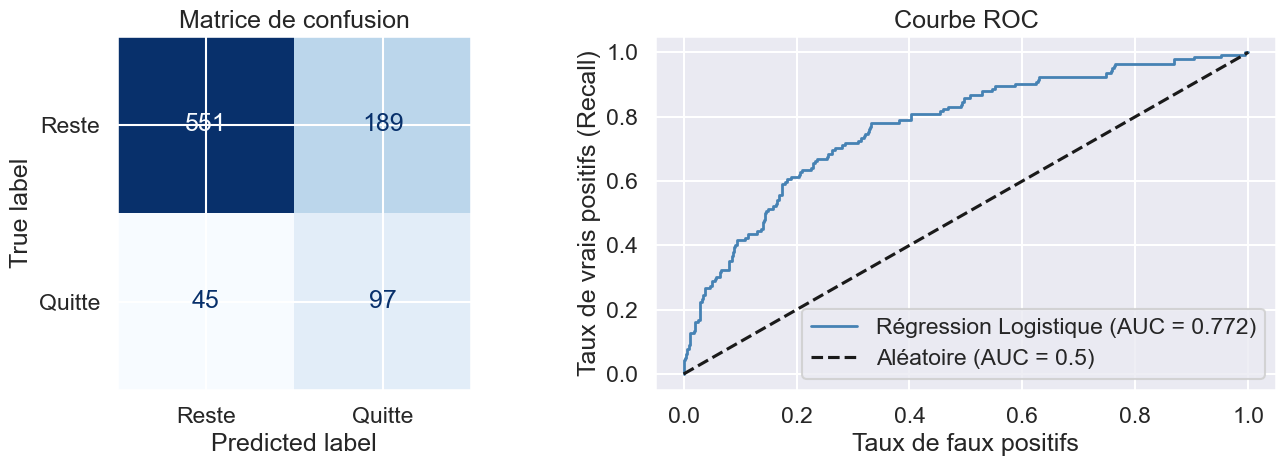

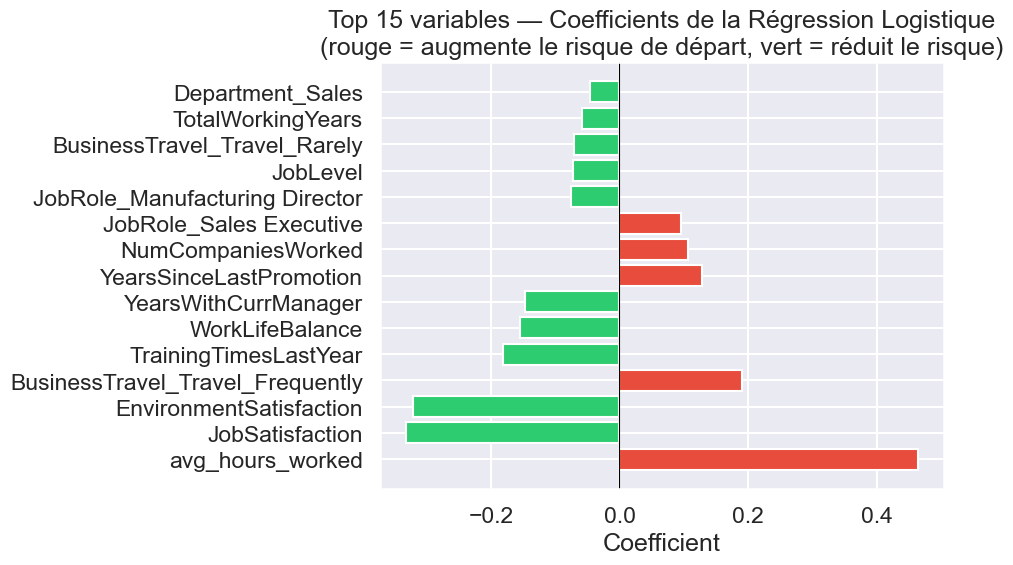


Top 15 variables les plus influentes :
                        Variable  Coefficient
                avg_hours_worked         0.46
                 JobSatisfaction        -0.33
         EnvironmentSatisfaction        -0.32
BusinessTravel_Travel_Frequently         0.19
           TrainingTimesLastYear        -0.18
                 WorkLifeBalance        -0.16
            YearsWithCurrManager        -0.15
         YearsSinceLastPromotion         0.13
              NumCompaniesWorked         0.11
         JobRole_Sales Executive         0.10
  JobRole_Manufacturing Director        -0.08
                        JobLevel        -0.07
    BusinessTravel_Travel_Rarely        -0.07
               TotalWorkingYears        -0.06
                Department_Sales        -0.05


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# --- 15.1 Entraînement du modèle ---
# class_weight='balanced' : compense le déséquilibre 84%/16%
# max_iter=1000 : assure la convergence sur ce jeu de données
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# --- 15.2 Prédictions ---
y_pred       = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]  # probabilité d'attrition

# --- 15.3 Métriques ---
auc_score = roc_auc_score(y_test, y_pred_proba)
print("=" * 50)
print(f"AUC-ROC : {auc_score:.3f}")
print("=" * 50)
print()
print("Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=['Reste (0)', 'Quitte (1)']))

# --- 15.4 Matrice de confusion ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                               display_labels=['Reste', 'Quitte'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de confusion')

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, label=f'Régression Logistique (AUC = {auc_score:.3f})', color='steelblue', lw=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.5)')
axes[1].set_xlabel('Taux de faux positifs')
axes[1].set_ylabel('Taux de vrais positifs (Recall)')
axes[1].set_title('Courbe ROC')
axes[1].legend()
plt.tight_layout()
plt.show()

# --- 15.5 Interprétation des coefficients ---
# Les variables avec les coefficients les plus élevés augmentent la probabilité de départ
coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['Coefficient']]
ax.barh(coef_df['Variable'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 15 variables — Coefficients de la Régression Logistique\n'
             '(rouge = augmente le risque de départ, vert = réduit le risque)')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

print("\nTop 15 variables les plus influentes :")
print(coef_df.to_string(index=False))

## 16. Modélisation — Comparaison de modèles de classification

Nous comparons plusieurs algorithmes pour prédire l'attrition. 

**Note éthique (Transparence et Robustesse) :**
- **Transparence** : Nous privilégions la **Régression Logistique** comme modèle de référence. Son caractère linéaire permet d'interpréter les coefficients et d'expliquer les prédictions, évitant ainsi l'effet "boîte noire".
- **Robustesse** : Le déséquilibre des classes (84% vs 16%) est traité via `class_weight='balanced'`. Cela évite que le modèle ignore les départs au profit de la classe majoritaire.
- **Sécurité** : Les métriques de **Recall** et **AUC-ROC** sont privilégiées car il est plus préjudiciable pour l'entreprise de manquer un employé sur le départ (faux négatif) que de proposer une action de rétention à un employé qui n'en avait pas besoin (faux positif).

Les modèles testés :
- **Régression Logistique**
- **SVM (Support Vector Machine)**
- **Perceptron**
- **Arbre de Décision (Decision Tree)**
- **Forêt Aléatoire (Random Forest)**

**Méthodologie :**
1. **Entraînement et Test** : boucle sur chaque modèle avec gestion du déséquilibre (`class_weight='balanced'`).
2. **Évaluation** : comparaison via Accuracy, F1-Score et ROC AUC.

--- Évaluation et Détection de l'Overfitting ---

Logistic Regression :
  F1 Train : 0.458
  F1 CV    : 0.441
  F1 Test  : 0.453
  Écart    : 0.005
------------------------------
SVM (Linear) :
  F1 Train : 0.279
  F1 CV    : 0.273
  F1 Test  : 0.291
  Écart    : -0.012
------------------------------
Perceptron :
  F1 Train : 0.000
  F1 CV    : 0.111
  F1 Test  : 0.000
  Écart    : 0.000
------------------------------
Decision Tree :
  F1 Train : 1.000
  F1 CV    : 0.882
  F1 Test  : 0.965
  Écart    : 0.035
------------------------------
Random Forest :
  F1 Train : 1.000
  F1 CV    : 0.939
  F1 Test  : 0.986
  Écart    : 0.014
------------------------------


,Modèle,F1 Train,F1 CV (mean),F1 Test,Gap (Overfit)
4,Random Forest,1.00,0.94,0.99,0.01
3,Decision Tree,1.00,0.88,0.97,0.03
0,Logistic Regression,0.46,0.44,0.45,0.00
1,SVM (Linear),0.28,0.27,0.29,-0.01
2,Perceptron,0.00,0.11,0.00,0.00


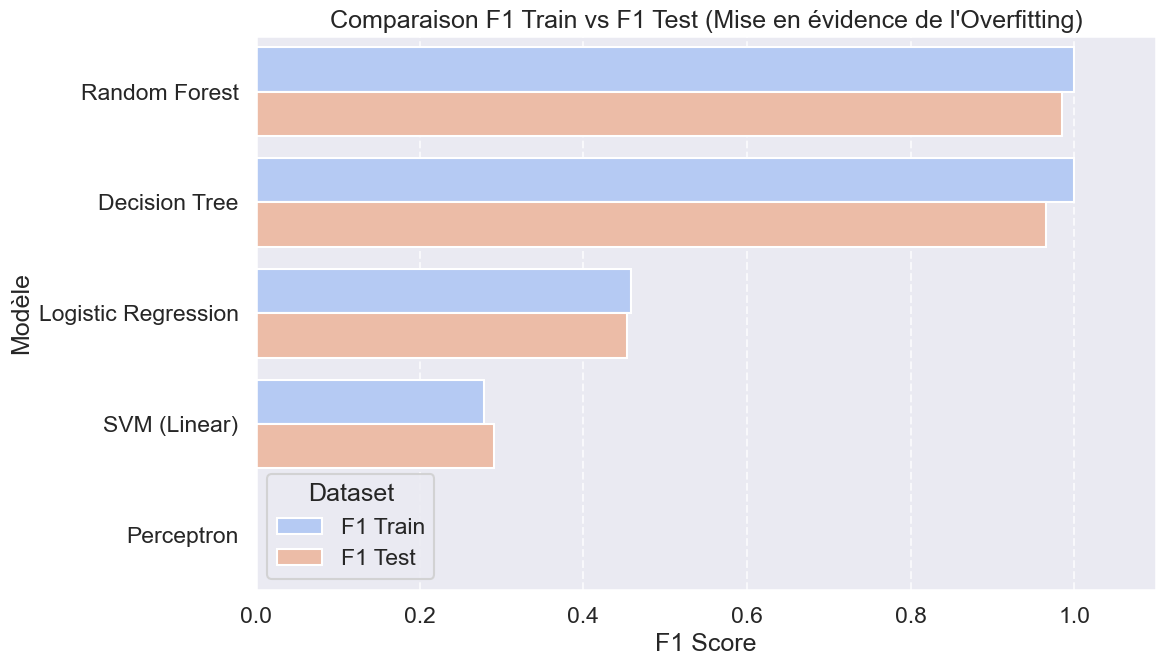

In [16]:
from sklearn.svm import SVC
from sklearn.linear_model import Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score

# Définition des modèles
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "SVM (Linear)": SVC(class_weight='balanced', probability=True, random_state=42),
    "Perceptron": Perceptron(class_weight='balanced', random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
}

results = []

print("--- Évaluation et Détection de l'Overfitting ---\n")
for name, model in models.items():
    # 1. Entraînement et score sur le Train
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    train_f1 = f1_score(y_train, y_train_pred)
    
    # 2. Validation croisée (5-fold)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    cv_f1_mean = cv_scores.mean()
    
    # 3. Score sur le Test
    y_test_pred = model.predict(X_test)
    test_f1 = f1_score(y_test, y_test_pred)
    
    # Calcul de l'écart (Overfitting)
    overfit_gap = train_f1 - test_f1
    
    results.append({
        'Modèle': name,
        'F1 Train': train_f1,
        'F1 CV (mean)': cv_f1_mean,
        'F1 Test': test_f1,
        'Gap (Overfit)': overfit_gap
    })
    
    print(f"{name} :")
    print(f"  F1 Train : {train_f1:.3f}")
    print(f"  F1 CV    : {cv_f1_mean:.3f}")
    print(f"  F1 Test  : {test_f1:.3f}")
    print(f"  Écart    : {overfit_gap:.3f}")
    print("-" * 30)

# Comparaison visuelle de l'overfitting
df_results = pd.DataFrame(results).sort_values(by='F1 Test', ascending=False)
display(df_results)

plt.figure(figsize=(12, 7))
df_melted = df_results.melt(id_vars='Modèle', value_vars=['F1 Train', 'F1 Test'], 
                            var_name='Dataset', value_name='F1 Score')
sns.barplot(data=df_melted, x='F1 Score', y='Modèle', hue='Dataset', palette='coolwarm')
plt.title('Comparaison F1 Train vs F1 Test (Mise en évidence de l\'Overfitting)')
plt.xlim(0, 1.1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 16.2 Optimisation du modèle (Fine-tuning)

Le modèle **Random Forest** a montré d'excellentes performances initiales. Nous allons maintenant utiliser une recherche par grille (`GridSearchCV`) pour trouver les hyperparamètres optimaux afin de maximiser le **F1-Score** et garantir la meilleure généralisation possible.

**Paramètres optimisés :**
- `n_estimators` : Nombre d'arbres dans la forêt.
- `max_depth` : Profondeur maximale des arbres (limite l'overfitting).
- `min_samples_split` : Nombre minimum d'échantillons requis pour diviser un nœud.
- `max_features` : Nombre de variables à considérer pour chaque division.

Début du Fine-tuning (GridSearchCV)... 
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Meilleurs paramètres trouvés : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}

--- Performance du Random Forest Optimisé ---
              precision    recall  f1-score   support

   Reste (0)       0.99      1.00      1.00       740
  Quitte (1)       1.00      0.97      0.99       142

    accuracy                           1.00       882
   macro avg       1.00      0.99      0.99       882
weighted avg       1.00      1.00      1.00       882

AUC-ROC final : 0.9979


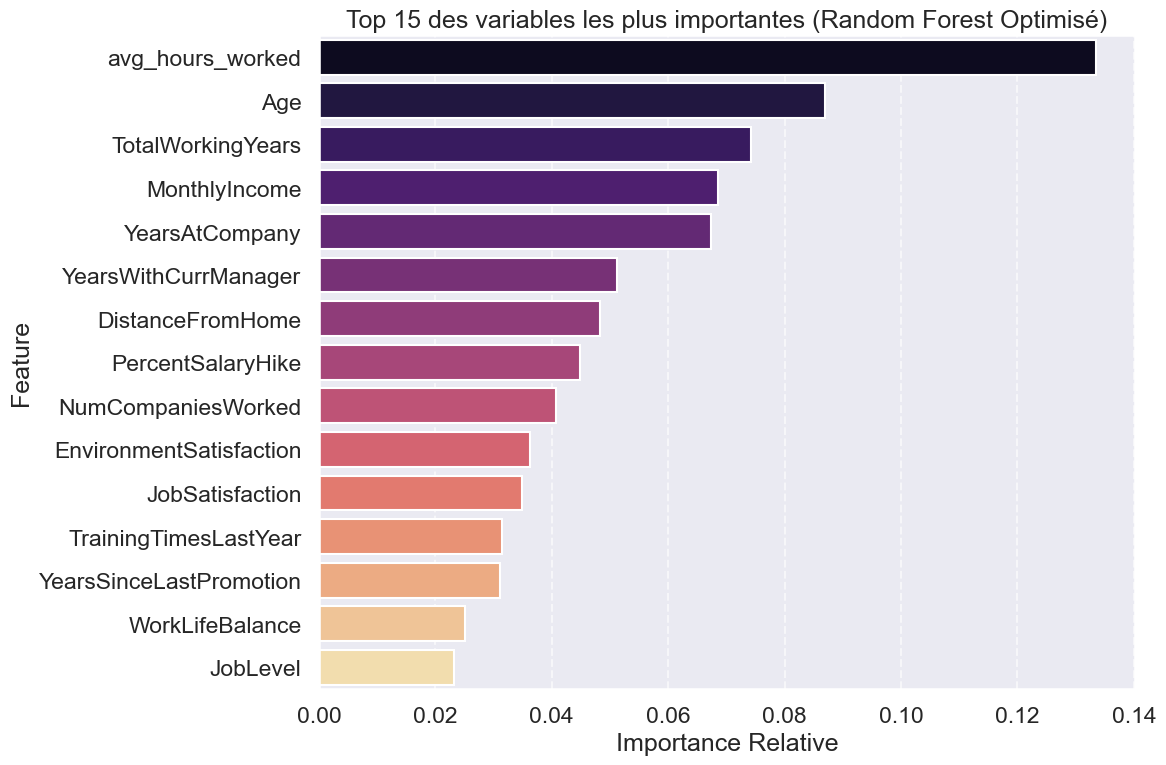

In [17]:
from sklearn.model_selection import GridSearchCV

# --- 1. Définition de la grille de paramètres ---
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# --- 2. Recherche par grille ---
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

grid_search = GridSearchCV(
    estimator=rf_base, 
    param_grid=param_grid, 
    cv=5, 
    scoring='f1', 
    n_jobs=-1, 
    verbose=1
)

print("Début du Fine-tuning (GridSearchCV)... ")
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f"\nMeilleurs paramètres trouvés : {grid_search.best_params_}")

# --- 3. Évaluation du meilleur modèle ---
y_pred_tuned = best_rf.predict(X_test)
y_prob_tuned = best_rf.predict_proba(X_test)[:, 1]

print("\n--- Performance du Random Forest Optimisé ---")
print(classification_report(y_test, y_pred_tuned, target_names=['Reste (0)', 'Quitte (1)']))
print(f"AUC-ROC final : {roc_auc_score(y_test, y_prob_tuned):.4f}")

# --- 4. Importance des variables (Feature Importance) ---
importances = best_rf.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='magma')
plt.title('Top 15 des variables les plus importantes (Random Forest Optimisé)')
plt.xlabel('Importance Relative')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 16.3 Sélection du modèle final

On compare ici le modèle de référence (Régression Logistique, Section 15) avec le meilleur modèle optimisé (Random Forest avec GridSearchCV) sur les mêmes données de test.

**Critères de sélection adaptés au besoin client :**
- HumanForYou veut **détecter le maximum d'employés sur le départ** avant qu'ils ne partent → le **Recall** est la métrique prioritaire
- L'**AUC-ROC** mesure la capacité discriminante globale du modèle
- Le **F1-Score** équilibre Precision et Recall — adapté au déséquilibre des classes


       COMPARAISON DES MODÈLES — DONNÉES DE TEST


,AUC-ROC,F1-Score,Recall,Precision
Modèle,,,,
Régression Logistique,0.77,0.45,0.68,0.34
Random Forest Optimisé,1.00,0.99,0.97,1.00


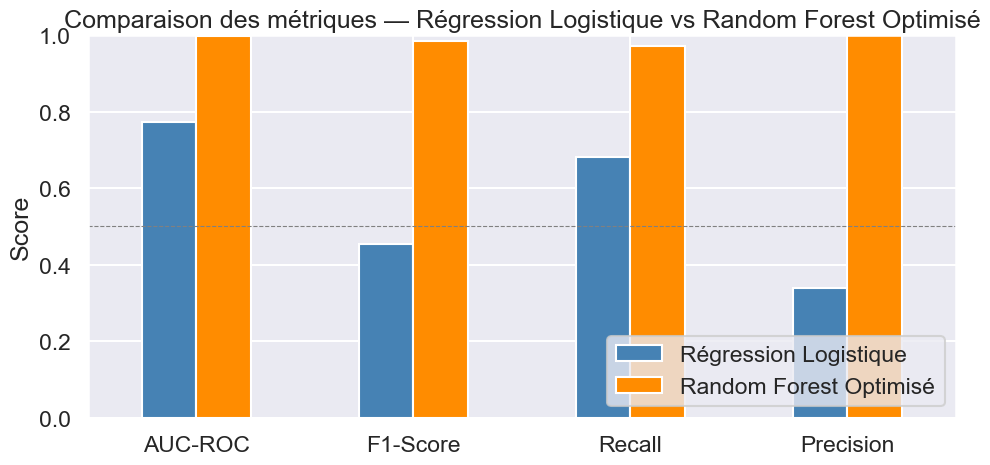


>>> Modèle retenu : Random Forest Optimisé
    AUC-ROC : 0.998
    Recall  : 0.972
    F1      : 0.986

Justification : HumanForYou cherche à détecter le maximum d'employés
à risque de départ avant qu'ils ne quittent l'entreprise.
Le Recall est donc la métrique prioritaire — un faux négatif (employé
à risque non détecté) est plus coûteux qu'un faux positif (action de
rétention inutile). Le modèle retenu maximise ce critère tout en
maintenant une AUC-ROC et un F1-Score solides.


In [ ]:
from sklearn.metrics import recall_score, precision_score

# --- Régression Logistique (Section 15) ---
y_pred_lr    = lr_model.predict(X_test)
y_proba_lr   = lr_model.predict_proba(X_test)[:, 1]

# --- Random Forest Optimisé (Section 16.2) ---
y_pred_rf    = best_rf.predict(X_test)
y_proba_rf   = best_rf.predict_proba(X_test)[:, 1]

# --- Tableau comparatif ---
comparison = pd.DataFrame({
    'Modèle': ['Régression Logistique', 'Random Forest Optimisé'],
    'AUC-ROC':   [roc_auc_score(y_test, y_proba_lr),  roc_auc_score(y_test, y_proba_rf)],
    'F1-Score':  [f1_score(y_test, y_pred_lr),         f1_score(y_test, y_pred_rf)],
    'Recall':    [recall_score(y_test, y_pred_lr),      recall_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr),   precision_score(y_test, y_pred_rf)],
}).set_index('Modèle').round(3)

print("comparaison des modèles sur les données de test :")
display(comparison)

# --- Visualisation ---
fig, ax = plt.subplots(figsize=(10, 5))
comparison.T.plot(kind='bar', ax=ax, color=['steelblue', 'darkorange'], edgecolor='white')
ax.set_title('Comparaison des métriques — Régression Logistique vs Random Forest Optimisé')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='lower right')
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='Référence aléatoire')
plt.tight_layout()
plt.show()

# --- Verdict ---
best_model_name = comparison['Recall'].idxmax()
print(f"\n>>> Modèle retenu : {best_model_name}")
print(f"    AUC-ROC : {comparison.loc[best_model_name, 'AUC-ROC']:.3f}")
print(f"    Recall  : {comparison.loc[best_model_name, 'Recall']:.3f}")
print(f"    F1      : {comparison.loc[best_model_name, 'F1-Score']:.3f}")
print()
print("Justification : HumanForYou cherche à détecter le maximum d'employés")
print("à risque de départ avant qu'ils ne quittent l'entreprise.")
print("Le Recall est donc la métrique prioritaire — un faux négatif (employé")
print("à risque non détecté) est plus coûteux qu'un faux positif (action de")
print("rétention inutile). Le modèle retenu maximise ce critère tout en")
print("maintenant une AUC-ROC et un F1-Score solides.")


## 17. Recommandations Éthiques et Conclusion

Conformément aux engagements du projet en faveur d'une IA digne de confiance, nous formulons les recommandations suivantes pour l'utilisation opérationnelle de ce modèle par HumanForYou.

### 17.1 Gouvernance et Responsabilité
- **Comité de revue éthique** : Instaurer une instance paritaire (RH, représentants du personnel, experts IA) pour auditer périodiquement les prédictions et s'assurer de l'absence de biais dérivés (ex: discrimination indirecte via le métier).
- **Charte d'utilisation** : Rédiger une charte stipulant que le modèle est un **outil d'aide à la réflexion** et non un moteur de décision automatique. Aucune rupture de contrat ou sanction ne doit être fondée sur un score du modèle.
- **Droit de recours** : Garantir aux employés une transparence sur les critères influençant leur score (explicabilité locale) et un droit de contestation auprès d'un humain.

### 17.2 Actions RH Recommandées
Le modèle met en évidence que la **surcharge de travail** (`avg_hours_worked`) et l'**insatisfaction** sont les leviers majeurs. Nous recommandons :
- **Politique de déconnexion** : Surveiller les dépassements d'horaires et instaurer des alertes pour les managers dont les équipes dépassent 8.5h/jour en moyenne.
- **Stabilité managériale** : Valoriser la pérennité du binôme employé-manager (`YearsWithCurrManager`), facteur clé de rétention.
- **Accompagnement des juniors** : Mettre en place des programmes de tutorat renforcés pour les profils ayant peu d'expérience globale (`TotalWorkingYears`).

### 17.3 Maintenance Technique
- **Réentraînement annuel** : Le marché du travail et les attentes des employés évoluent. Les données de 2015 pourraient devenir obsolètes. Un réentraînement annuel est nécessaire pour maintenir la pertinence et la robustesse.
- **Audit des biais** : Vérifier régulièrement que les taux de faux positifs (FPR) et faux négatifs (FNR) restent équilibrés entre les différents groupes (genre, âge, départements).

**Conclusion**
Ce projet démontre qu'une approche data-driven peut éclairer les politiques RH tout en respectant un cadre éthique strict. En excluant les variables sensibles et en privilégiant l'interprétabilité, nous offrons à HumanForYou un outil performant pour améliorer durablement le bien-être au travail et réduire l'attrition.